# Further manual baseline analysis
- Our analysis of the baselines from before all worked but this I think was because it always found the short and mid terms in the LSP.
- I want to verify this on data where the LSP only found one of either the short or mid terms.
- This causes a fallback to the SM2016 relation, allowing us to verify it.
- Furthermore, it allows us to test what tolerance we should on the optimisation bounds relative to the priors: logically, any prior that was not found during the LSP phase and is from the SM2016 should have larger tolerances and then for the fallback to the mean the bounds should be even less restrictive.
- Furthermore, I want to test what it would be like if the q bounds for long term was less restrictive. In theory it could be instrument drift as rather than any Gleissberg type cycle. As such, it is not strictly cyclical. Let's compare the performance.
---


- Let's start by making a local copy of the GPR pipeline.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import minimize

import celerite2
from celerite2 import terms

from prettytable import PrettyTable

import sys
from pathlib import Path

sys.path.append(str(Path('../..').resolve()))

from helpers.df_ops import prepare_df, split_df, clean_df
from helpers.priors import find_classify_signals, get_priors

def set_params(log_params, k, gp):
    # k = len(log_params) // 3
    params = np.exp(log_params)
    sigmas = params[0:k]
    rhos = params[k:2*k]
    qs = params[2*k::]
    
    gp.kernel = terms.SHOTerm(sigma=sigmas[0], rho=rhos[0], Q=qs[0])
    for k_idx in range(1,k):
        gp.kernel += terms.SHOTerm(sigma=sigmas[k_idx], rho=rhos[k_idx], Q=qs[k_idx])
    return gp

def NLL(log_params, gp, k, y):
    '''
    Calculates the NLL of a set of parameters for a local gp
    '''
    gp = set_params(log_params, k, gp)
    gp.recompute(quiet=True)
    return -gp.log_likelihood(y)

def train_gpr(
        datapath,
        add_prefix: bool = False, # whether or not to add the 240000 to the JD
        train_split: float = 0.8, valid_split: float = 0.19,
        star_type: str = None, star_name: str = None,
        error_percent: float = 2.5, # the percentage error of the input
        sigma_upper_mult: float = 5.0, rho_bound_mults = [0.9, 1.1], q_bounds_in = [5, 100],
        relative: bool = True, # Plot data with relative dates
        verbose = True, plot = True, # general outputs
        loop_verbose: bool = False, loop_plot: bool = False, loop_savefigs: bool = True, # output within the loop
        results_verbose: bool = True, results_plot: bool = True, ax = None, # output the results
        require_mid: bool = True, # discard kernel combos with no mid-range term (prevents underfitting with sparse data)
        SEED = 1701
        ):
        # Read the data into a "raw" df
        raw_df = pd.read_csv(datapath, sep=r'\s+', skip_blank_lines=True)

        # Prep the df adds the column names etc
        data_df = prepare_df(raw_df, add_prefix=add_prefix, relative=relative)

        # Split the data
        dirty_train_df, valid_df, test_df = split_df(data_df,
                                                     train_split=train_split, valid_split=valid_split)

        # Clean the dataset for outliers
        train_df = clean_df(dirty_train_df, tol=4,
                                verbose=verbose, plot=plot)

        # Classify signal data and get priors
        classified_signal_data = find_classify_signals(dirty_train_df,
                                                plot_fitpeaks=plot, verbose_fitpeaks=verbose,
                                                plot_genpriors=plot, verbose_genpriors=verbose)
        priors = get_priors(classified_signal_data,
                                        star_type=star_type,
                                        verbose=verbose)

        #-----Do the model training and comparison---------
        train_yerr = train_df['sind'] * error_percent / 100

        train_mean = train_df['sind'].mean()
        train_std  = train_df['sind'].std()

        # Define the prior combos to try
        prior_combos = {
        "1s":   (1, [priors['short']]),
        "1m":   (1, [priors['mid']]),
        "1l":   (1, [priors['long']]),

        "2sm":  (2, [priors['short'], priors['mid']]),
        "2ml":  (2, [priors['mid'],   priors['long']]),
        "2ls":  (2, [priors['long'],  priors['short']]),

        "3sml": (3, [priors['short'], priors['mid'], priors['long']]),
        }

        if require_mid:
                prior_combos = {k: v for k, v in prior_combos.items() if priors['mid'] in v[1]}

        # Set up the loop
        best_combo  = None
        best_NLPD   = np.inf
        best_gp     = None
        best_params = None

        # Run the loop
        for combo_name, (k, prior_combo) in prior_combos.items():
                np.random.seed(SEED)

                sigma_0s = [train_std / k for _ in range(k)]
                rho_0s   = prior_combo
                q_0s     = [np.random.uniform(0.5, 1) for _ in range(k)]

                initial_guess = np.concatenate([
                        np.log(sigma_0s),
                        np.log(rho_0s),
                        np.log(q_0s)
                ])

                sigma_upper  = train_std * sigma_upper_mult
                sigma_bounds = [(np.log(1e-4), np.log(sigma_upper)) for _ in range(k)]
                rho_bounds   = [(np.log(rho * rho_bound_mults[0]), np.log(rho * rho_bound_mults[1])) for rho in rho_0s]
                q_bounds     = [(np.log(q_bounds_in[0]), np.log(q_bounds_in[1])) for _ in range(k)]

                bounds = np.concatenate([sigma_bounds, rho_bounds, q_bounds])

                # Create the initial kernel for this iteration
                kernel = terms.SHOTerm(sigma=sigma_0s[0], rho=rho_0s[0], Q=q_0s[0])
                for k_idx in range(1, k):
                        kernel += terms.SHOTerm(sigma=sigma_0s[k_idx], rho=rho_0s[k_idx], Q=q_0s[k_idx])

                # Define and compute the GP
                gp = celerite2.GaussianProcess(kernel, mean=train_mean)
                gp.compute(train_df['day'], yerr=train_yerr)

                # Train the GP
                gp_results = minimize(
                        NLL, initial_guess,
                        args=(gp, k, train_df['sind'].to_numpy()),
                        method='L-BFGS-B',
                        bounds=bounds
                        )

                gp   = set_params(gp_results.x, k, gp)
                gp.recompute()
                best = np.exp(gp_results.x)

                if loop_verbose:
                        table = PrettyTable(["sigma", "Q", "rho (days)", "rho (years)"])
                        best_sigmas = best[0:k]
                        best_rhos   = best[k:2*k]
                        best_qs     = best[2*k:]
                        for k_idx in range(k):
                                table.add_row([f"{best_sigmas[k_idx]:.4f}", f"{best_qs[k_idx]:.2f}",
                                               f"{best_rhos[k_idx]:.2f}", f"{best_rhos[k_idx]/365:.2f}"])
                        print(gp_results.success, gp_results.message)
                        print(f"For k = {k}")
                        print(table)

                # Predict on validation set
                mu, cov = gp.predict(train_df['sind'], t=valid_df['day'], return_var=True)
                std = np.sqrt(cov)

                # Model comparison via NLPD
                y_valid    = valid_df['sind'].to_numpy()
                valid_yerr = valid_df['sind'] * error_percent / 100
                total_var  = cov + valid_yerr**2
                nlpd_per_point = 0.5 * np.log(2 * np.pi * total_var) + (y_valid - mu)**2 / (2 * total_var)
                mean_nlpd = nlpd_per_point.mean()

                if mean_nlpd < best_NLPD:
                        best_combo  = combo_name
                        best_NLPD   = mean_nlpd
                        best_gp     = gp
                        best_params = best

                if loop_plot:
                        loop_fig, loop_ax = plt.subplots(figsize=(20, 5))
                        loop_ax.scatter(train_df['year'], train_df['sind'], color='blue', label='Training', marker='x')
                        loop_ax.plot(valid_df['year'], valid_df['sind'], color='orange', label='Actual', alpha=0.5)
                        
                        loop_ax.set_title(star_name + " " + combo_name)

                        loop_ax.plot(valid_df['year'], mu, color='green', label='Predictions')
                        loop_ax.fill_between(valid_df['year'], mu - std, mu + std,
                                             color='green', alpha=0.2, label='Uncertainties')
                        
                        loop_ax.legend()

                        loop_ax.text(0.02, 0.05, f"NLPD = {mean_nlpd:.4f}",
                                transform=loop_ax.transAxes, fontsize=10, verticalalignment='bottom',
                                bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
                        
                        if loop_savefigs:
                                loop_fig.savefig(f"./figs/gpr_{star_name}_{int(round(train_split * 100)):02d}_{combo_name}.png", dpi=100, bbox_inches='tight')
                                plt.close(loop_fig)

                        else:
                                plt.show()

                if loop_verbose:
                        print(f"Mean NLPD on validation set ({combo_name}): {mean_nlpd:.4f}")

        #-------Now we have the best model------

        # Predict the best model once
        mu, cov = best_gp.predict(train_df['sind'], t=valid_df['day'], return_var=True)
        std = np.sqrt(cov)
        results = pd.DataFrame({
                'forecast': mu,
                'lower':    mu - std,
                'upper':    mu + std,
        }, index=valid_df.index)

        if results_verbose: # Print best model params
                print(f"The best params were found for {best_combo} with NLPD of {best_NLPD}.")
                (k, prior_combo) = prior_combos[best_combo]
                table = PrettyTable(["sigma", "Q", "rho (days)", "rho (years)"])
                best_sigmas = best_params[0:k]
                best_rhos   = best_params[k:2*k]
                best_qs     = best_params[2*k:]
                for k_idx in range(k):
                        table.add_row([f"{best_sigmas[k_idx]:.4f}", f"{best_qs[k_idx]:.2f}",
                                       f"{best_rhos[k_idx]:.2f}", f"{best_rhos[k_idx]/365:.2f}"])
                print(table)

        if results_plot: # Plot best model predictions
                if ax is None: # Enables passthrough
                        fig, ax = plt.subplots(figsize=(20, 5))
                ax.scatter(train_df['year'], train_df['sind'], color='blue', label='Training', marker='x')
                ax.scatter(valid_df['year'], valid_df['sind'], color='orange', label='Actual', alpha=0.5)
                ax.set_title(f"Best model for {star_name} is {best_combo}")
                ax.plot(valid_df['year'], results['forecast'], color='green', label='Predictions')
                ax.fill_between(valid_df['year'], results['lower'], results['upper'],
                                color='green', alpha=0.2, label='Uncertainties')
                ax.legend()
                ax.text(0.02, 0.05, f"NLPD = {best_NLPD:.4f}",
                        transform=ax.transAxes, fontsize=10, verticalalignment='bottom',
                        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

        return best_gp

- Alrighty. Let us run the prior checks on a few stars until we find ones that only return one of the short or mid.
- hd17361_caii.txt has only the mid cycle.



Removed 0 datapoints which had NaN.
Removed 2 datapoints that were deemed ourliers by tolerance in sind of 4 times MAD.


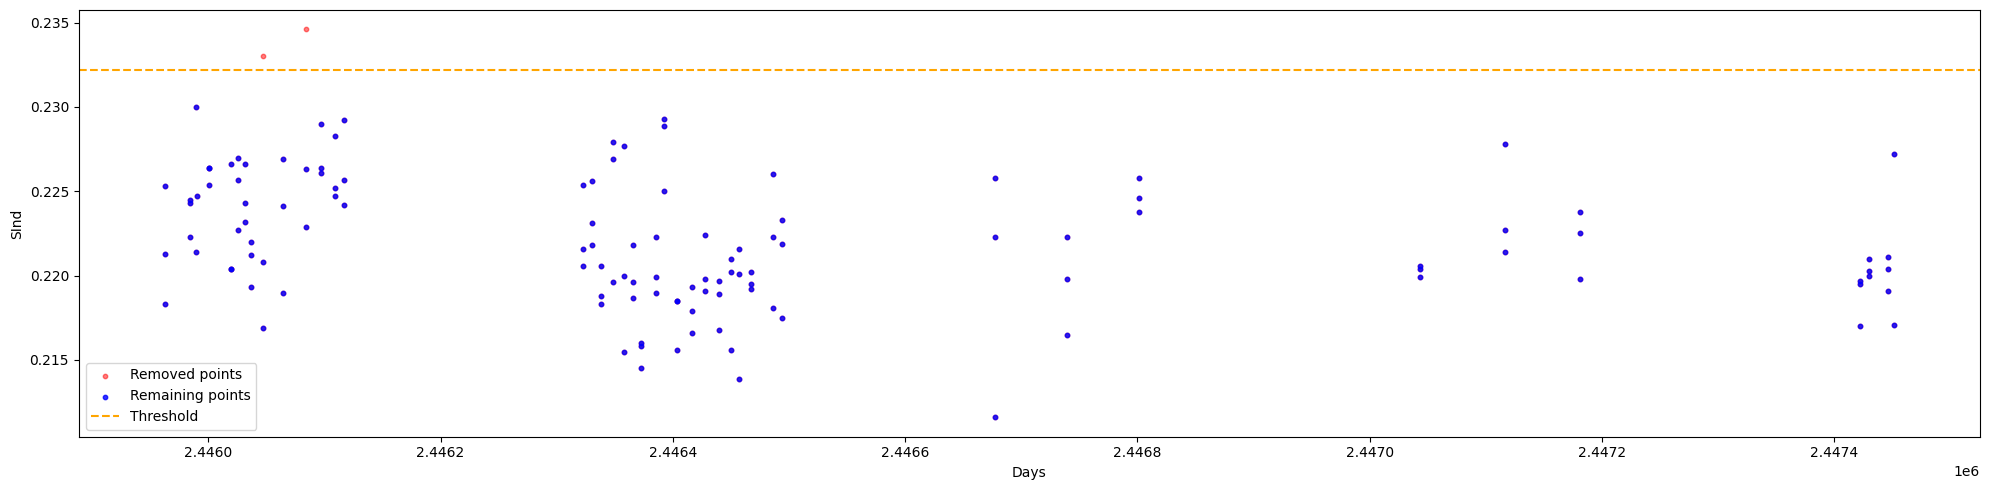

C:\Users\Joey\Desktop\Cambridge\Work\Thesis\helpers\LSP_peaks.py:173: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data_timeframe = t[-1] - t[0]


In iteration 0, period at 804.93 days was accepted.


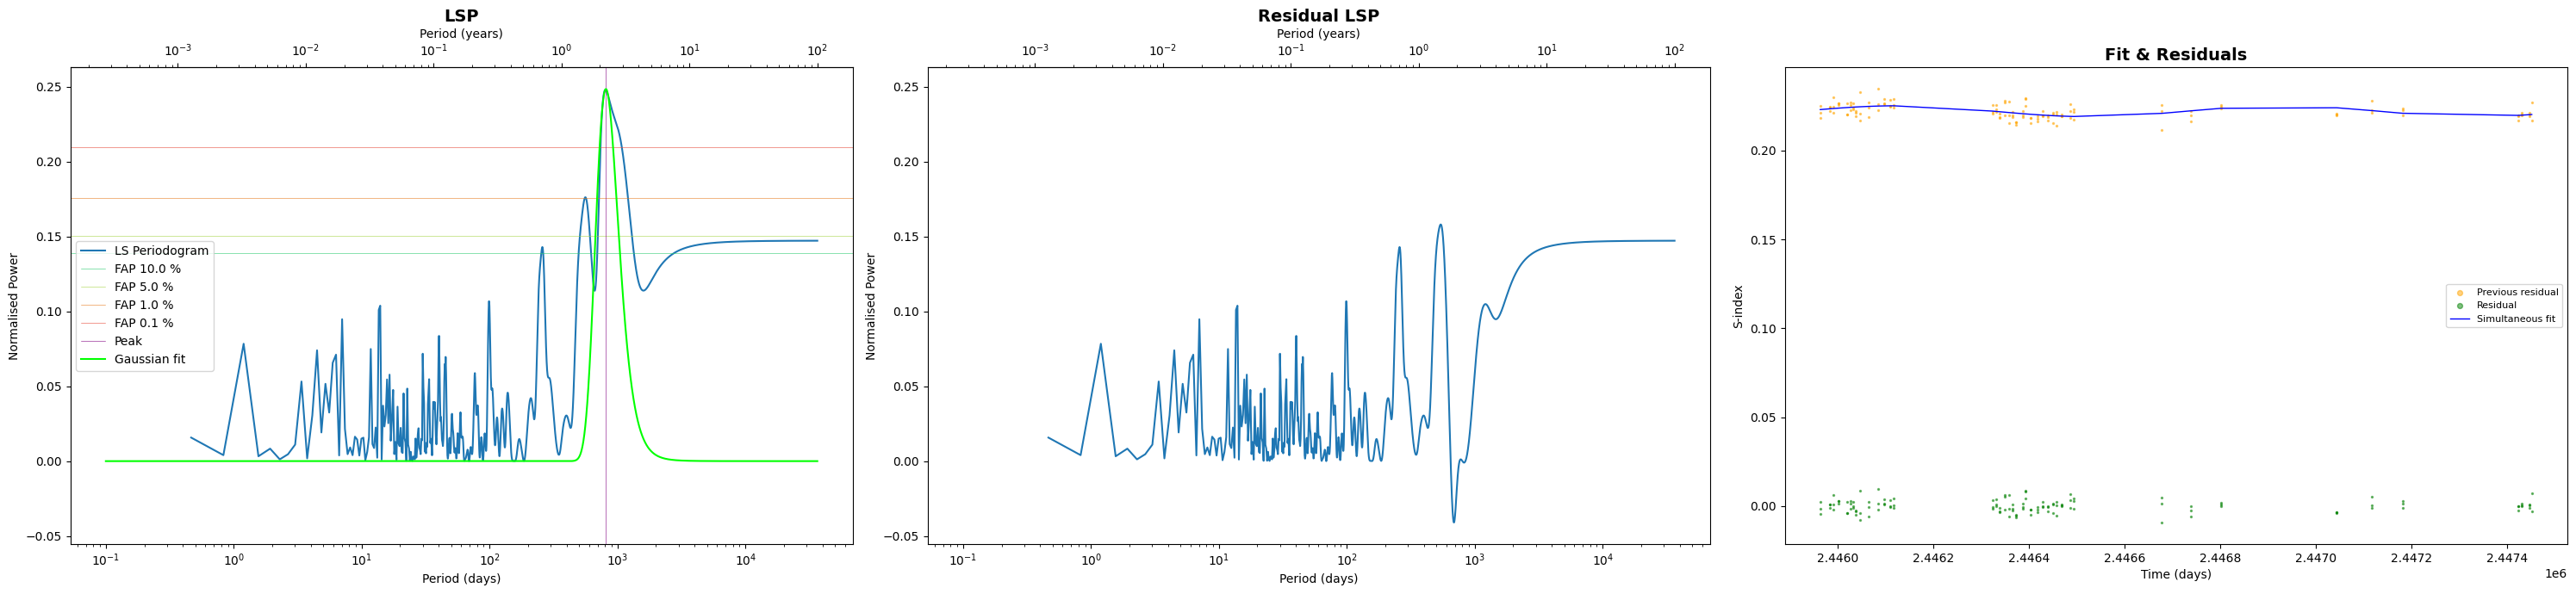

Accepted periods and their heights
+--------+-------+--------+--------+
|  Days  | Years | Height |  SNR   |
+--------+-------+--------+--------+
| 804.93 |  2.21 | 0.2479 | 266.02 |
+--------+-------+--------+--------+


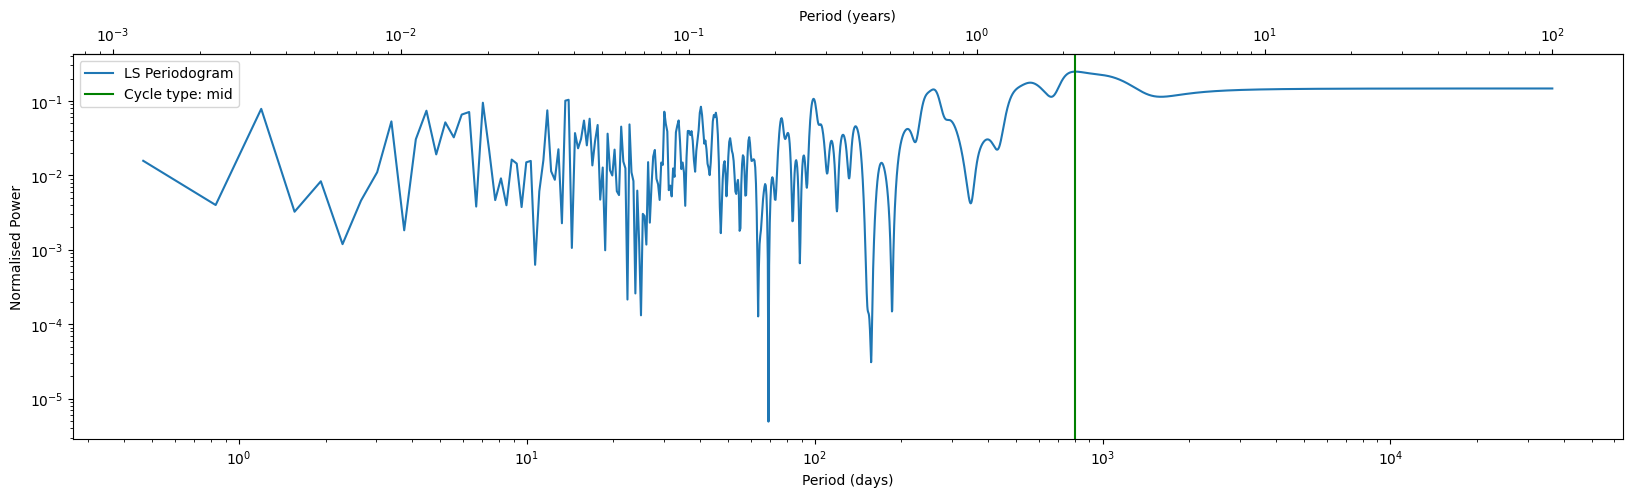

Classified Signals
+------------+------------+-------------+
| Cycle Type | Prior Days | Prior Years |
+------------+------------+-------------+
|    Mid     |   804.93   |     2.21    |
+------------+------------+-------------+


In [4]:
from helpers.priors import find_classify_signals

#--- set params

datapath = r"../../Data/hd17361_caii.txt"
add_prefix = True
relative = True
train_split = 0.8
valid_split = 0.19
verbose = True
plot = True

#---

raw_df = pd.read_csv(datapath, sep=r'\s+', skip_blank_lines=True)

# Prep the df adds the column names etc
data_df = prepare_df(raw_df, add_prefix=add_prefix, relative=relative)

# Split the data
dirty_train_df, valid_df, test_df = split_df(data_df,
                                                train_split=train_split, valid_split=valid_split)

# Clean the dataset for outliers
train_df = clean_df(dirty_train_df, tol=4,
                        verbose=verbose, plot=plot)

# Classify signal data and get priors
classified_signal_data = find_classify_signals(dirty_train_df,
                                        plot_fitpeaks=plot, verbose_fitpeaks=verbose,
                                        plot_genpriors=plot, verbose_genpriors=verbose)

In [5]:
classified_signal_data

{'mid': np.float64(804.9308433084332)}

- Great that's one down. Let's run this in a loop to see what we get.

In [13]:
import os
import matplotlib.pyplot as plt

# Change the limit to 100 (or any number you need)
plt.rcParams['figure.max_open_warning'] = 1000

#--- set params

datadir = r"../../Data/"
add_prefix = True
relative = True
train_split = 0.8
valid_split = 0.19
verbose = True
plot = False

#---

all_classified_signal_datas = {} # Stores the generated signal lists (filename, prior dict)

#--

for filename in os.listdir(datadir):
    if not filename.endswith(".txt"):
        continue

    datapath = os.path.join(datadir, filename)
    print(f"\nProcessing {filename}...")

    try:
        raw_df = pd.read_csv(datapath, sep=r'\s+', skip_blank_lines=True)

        # Prep the df adds the column names etc
        data_df = prepare_df(raw_df, add_prefix=add_prefix, relative=relative)

        # Split the data
        dirty_train_df, valid_df, test_df = split_df(data_df,
                                                        train_split=train_split, valid_split=valid_split)

        # Clean the dataset for outliers
        train_df = clean_df(dirty_train_df, tol=4,
                                verbose=verbose, plot=plot)

        # Classify signal data and get priors
        classified_signal_data = find_classify_signals(dirty_train_df,
                                                plot_fitpeaks=plot, verbose_fitpeaks=verbose,
                                                plot_genpriors=plot, verbose_genpriors=verbose)
        
        all_classified_signal_datas[filename] = classified_signal_data
        
    except Exception as e:
        print(f"Failed on {filename}: {e}")
        continue


Processing hd10072_caii.txt...
Removed 0 datapoints which had NaN.
Removed 24 datapoints that were deemed ourliers by tolerance in sind of 4 times MAD.


C:\Users\Joey\Desktop\Cambridge\Work\Thesis\helpers\LSP_peaks.py:173: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data_timeframe = t[-1] - t[0]


Peak at period 125.30 days was identified to be a window of 121.75 days by tolerance 0.03.
In iteration 0, period at 1516.69 days was accepted.
Peak at period 125.30 days was identified to be a window of 121.75 days by tolerance 0.03.
Peak at period 767.70 days was identified to be an alias of 1516.69 days at mult 0.50 by tolerance 0.01.
Peak at period 350.14 days was identified to be a window of 365.25 days by tolerance 0.04.
Peak at period 190.63 days was identified to be a window of 182.62 days by tolerance 0.04.
In iteration 1, period at 561.47 days was accepted.
Peak at period 125.66 days was identified to be a window of 121.75 days by tolerance 0.03.
Peak at period 726.09 days was identified to be an alias of 1516.69 days at mult 0.50 by tolerance 0.04.
Peak at period 351.96 days was identified to be a window of 365.25 days by tolerance 0.04.
Peak at period 189.17 days was identified to be an alias of 561.47 days at mult 0.33 by tolerance 0.01.
In iteration 2, period at 56.68 day

C:\Users\Joey\Desktop\Cambridge\Work\Thesis\helpers\LSP_peaks.py:173: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data_timeframe = t[-1] - t[0]


Accepted periods and their heights
+------+-------+--------+-----+
| Days | Years | Height | SNR |
+------+-------+--------+-----+
+------+-------+--------+-----+
Classified Signals
+------------+------------+-------------+
| Cycle Type | Prior Days | Prior Years |
+------------+------------+-------------+
+------------+------------+-------------+

Processing hd10780_caii.txt...
Removed 0 datapoints which had NaN.
Removed 17 datapoints that were deemed ourliers by tolerance in sind of 4 times MAD.


...

Peak at period 362.18 days was identified to be a window of 365.25 days by tolerance 0.01.
Peak at period 182.24 days was identified to be a window of 182.62 days by tolerance 0.00.
Peak at period 92.08 days was identified to be a window of 91.31 days by tolerance 0.01.
Iteration 0 did not find a frequency: terminating loop.
Accepted periods and their heights
+------+-------+--------+-----+
| Days | Years | Height | SNR |
+------+-------+--------+-----+
+------+-------+--------+-----+
Classified Signals
+------------+------------+-------------+
| Cycle Type | Prior Days | Prior Years |
+------------+------------+-------------+
+------------+------------+-------------+

Processing sol_sind_all.txt...
Removed 0 datapoints which had NaN.
Removed 57 datapoints that were deemed ourliers by tolerance in sind of 4 times MAD.


C:\Users\Joey\Desktop\Cambridge\Work\Thesis\helpers\LSP_peaks.py:173: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data_timeframe = t[-1] - t[0]


In iteration 0, period at 3817.30 days was accepted.
Peak at period 1947.39 days was identified to be an alias of 3817.30 days at mult 0.50 by tolerance 0.02.
Peak at period 14940.39 days was identified to be an alias of 3817.30 days at mult 4.00 by tolerance 0.02.
In iteration 1, period at 2891.65 days was accepted.
Peak at period 15120.70 days was identified to be an alias of 3817.30 days at mult 4.00 by tolerance 0.01.
Peak at period 1953.96 days was identified to be an alias of 3817.30 days at mult 0.50 by tolerance 0.02.
Period of 539.94 days has SNR of 3.857564529430236 < 5.
Peak at period 1300.60 days was identified to be an alias of 3817.30 days at mult 0.33 by tolerance 0.02.
In iteration 2, period at 832.67 days was accepted.
Peak at period 14666.64 days was identified to be an alias of 3817.30 days at mult 4.00 by tolerance 0.04.
Peak at period 1944.10 days was identified to be an alias of 3817.30 days at mult 0.50 by tolerance 0.02.
Peak at period 1295.49 days was identifie

C:\Users\Joey\Desktop\Cambridge\Work\Thesis\helpers\LSP_peaks.py:173: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data_timeframe = t[-1] - t[0]


In iteration 0, period at 3663.27 days was accepted.
In iteration 1, period at 2044.84 days was accepted.
In iteration 2, period at 821.36 days was accepted.
In iteration 3, period at 630.46 days was accepted.
In iteration 4, period at 451.97 days was accepted.
Peak at period 158.51 days was identified to be an alias of 630.46 days at mult 0.25 by tolerance 0.01.
Peak at period 278.23 days was identified to be an alias of 821.36 days at mult 0.33 by tolerance 0.02.
Period of 249.40 days has SNR of 4.4195219564601995 < 5.
Iteration 5 did not find a frequency: terminating loop.
Accepted periods and their heights
+---------+-------+--------+----------+
|   Days  | Years | Height |   SNR    |
+---------+-------+--------+----------+
| 3663.27 | 10.04 | 0.6576 | 78676.10 |
| 2044.84 |  5.60 | 0.1116 | 2843.46  |
|  821.36 |  2.25 | 0.0806 |  23.06   |
|  630.46 |  1.73 | 0.0537 |   8.89   |
|  451.97 |  1.24 | 0.0328 |   8.19   |
+---------+-------+--------+----------+
Classified Signals
+--

In [14]:
import pandas as pd

rows = []
for filename, signals in all_classified_signal_datas.items():
    rows.append({
        "Filename":   filename,
        "Short (d)":  round(signals['short'], 2)        if 'short' in signals else None,
        "Short (yr)": round(signals['short']/365.25, 2) if 'short' in signals else None,
        "Mid (d)":    round(signals['mid'], 2)          if 'mid'   in signals else None,
        "Mid (yr)":   round(signals['mid']/365.25, 2)   if 'mid'   in signals else None,
        "Long (d)":   round(signals['long'], 2)         if 'long'  in signals else None,
        "Long (yr)":  round(signals['long']/365.25, 2)  if 'long'  in signals else None,
    })

df = pd.DataFrame(rows).set_index("Filename")
df

,Short (d),Short (yr),Mid (d),Mid (yr),Long (d),Long (yr)
Filename,,,,,,
hd10072_caii.txt,56.68,0.16,1516.69,4.15,NaN,NaN
hd10700_caii.txt,NaN,NaN,NaN,NaN,NaN,NaN
hd10780_caii.txt,148.66,0.41,2237.20,6.13,NaN,NaN
hd11131_caii.txt,NaN,NaN,981.96,2.69,NaN,NaN
hd12235_caii.txt,140.26,0.38,788.51,2.16,NaN,NaN
hd123_caii.txt,NaN,NaN,603.08,1.65,NaN,NaN
hd12953_caii.txt,86.24,0.24,1822.19,4.99,NaN,NaN
hd13043_caii.txt,NaN,NaN,NaN,NaN,NaN,NaN
hd13421_caii.txt,NaN,NaN,727.55,1.99,NaN,NaN


In [15]:
df.to_csv("classified_signals.csv")


- In the future this could be used as a shortcut since the LSP takes so long. This is technically data leakage if we use a smaller training set but it will speed up the iteration process. *I will build a short_circuit thing into the function*. 
- Now let us examine what signals were found.

In [16]:
# Print which ones had 3sml, 2sm, 2sl, 2ml, 1s, 1m, 1l, 0.

def classify_row(row):
    has_s = pd.notna(row['Short (d)'])
    has_m = pd.notna(row['Mid (d)'])
    has_l = pd.notna(row['Long (d)'])

    if has_s and has_m and has_l: return '3sml'
    if has_s and has_m:           return '2sm'
    if has_s and has_l:           return '2sl'
    if has_m and has_l:           return '2ml'
    if has_s:                     return '1s'
    if has_m:                     return '1m'
    if has_l:                     return '1l'
    return '0'

df['detected'] = df.apply(classify_row, axis=1)

for label in ['3sml', '2sm', '2sl', '2ml', '1s', '1m', '1l', '0']:
    subset = df[df['detected'] == label].index.tolist()
    print(f"{label:>5} ({len(subset):2d}): {subset}")

 3sml ( 6): ['hd18256_caii.txt', 'hd1835_caii.txt', 'hd20630_caii.txt', 'hd22049_caii.txt', 'hd23249_caii.txt', 'sol_sind_all.txt']
  2sm (16): ['hd10072_caii.txt', 'hd10780_caii.txt', 'hd12235_caii.txt', 'hd12953_caii.txt', 'hd16160_caii.txt', 'hd20468_caii.txt', 'hd26923_caii.txt', 'hd26965_caii.txt', 'hd27022_caii.txt', 'hd27348_caii.txt', 'hd29139_caii.txt', 'hd29317_caii.txt', 'hd4128_caii.txt', 'hd4628_caii.txt', 'hd4628_Mt_wilson_data.txt', 'hd6920_caii.txt']
  2sl ( 0): []
  2ml ( 5): ['hd16673_caii.txt', 'hd17925_caii.txt', 'hd22072_caii.txt', 'hd3229_caii.txt', 'hd3651_caii.txt']
   1s ( 0): []
   1m (18): ['hd11131_caii.txt', 'hd123_caii.txt', 'hd13421_caii.txt', 'hd1388_caii.txt', 'hd17361_caii.txt', 'hd19787_caii.txt', 'hd21552_caii.txt', 'hd2454_caii.txt', 'hd24555_caii.txt', 'hd26913_caii.txt', 'hd28307_caii.txt', 'hd29645_caii.txt', 'hd30495_caii.txt', 'hd3795_caii.txt', 'hd4307_caii.txt', 'hd6903_caii.txt', 'hd7924_caii.txt', 'sol_sind_subset1_3.txt']
   1l ( 0): []
  

- Let's examine one of each manually and make the pipeline work for them.
- 3sml: hd18256
- 2sm: hd10072
- 2ml: hd16673
- 1m: hd11131
- 0: hd10700

## 3sml: HD18256


Removed 0 datapoints which had NaN.
Removed 12 datapoints that were deemed ourliers by tolerance in sind of 4 times MAD.


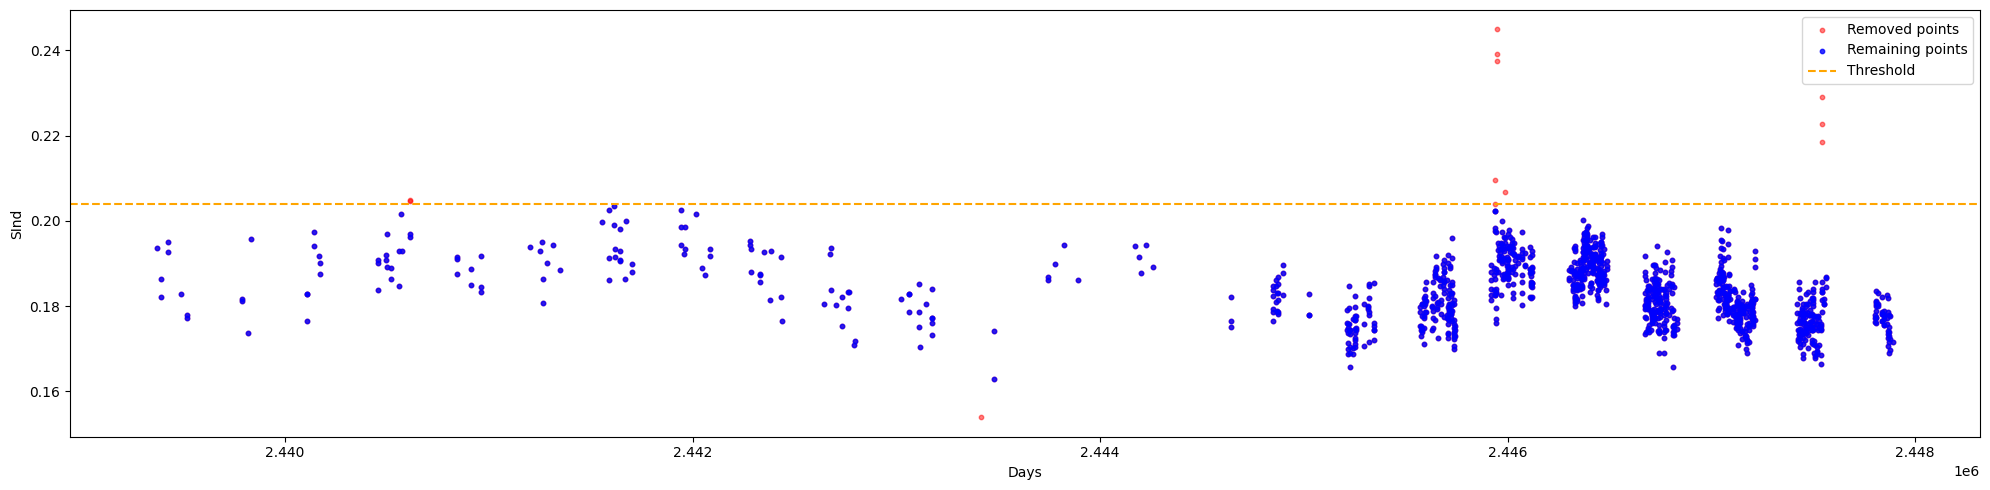

C:\Users\Joey\Desktop\Cambridge\Work\Thesis\helpers\LSP_peaks.py:173: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data_timeframe = t[-1] - t[0]


In iteration 0, period at 2120.40 days was accepted.
Peak at period 544.32 days was identified to be an alias of 2120.40 days at mult 0.25 by tolerance 0.03.
Peak at period 1110.80 days was identified to be an alias of 2120.40 days at mult 0.50 by tolerance 0.05.
In iteration 1, period at 581.91 days was accepted.
In iteration 2, period at 13977.15 days was accepted.
Peak at period 174.94 days was identified to be a window of 182.62 days by tolerance 0.04.
In iteration 3, period at 337.00 days was accepted.
Peak at period 84.42 days was identified to be an alias of 337.00 days at mult 0.25 by tolerance 0.00.
In iteration 4, period at 155.96 days was accepted.
Peak at period 1367.40 days was identified to be an alias of 337.00 days at mult 4.00 by tolerance 0.01.
Peak at period 84.42 days was identified to be an alias of 337.00 days at mult 0.25 by tolerance 0.00.
Peak at period 1125.04 days was identified to be an alias of 581.91 days at mult 2.00 by tolerance 0.03.
Iteration 5 did not

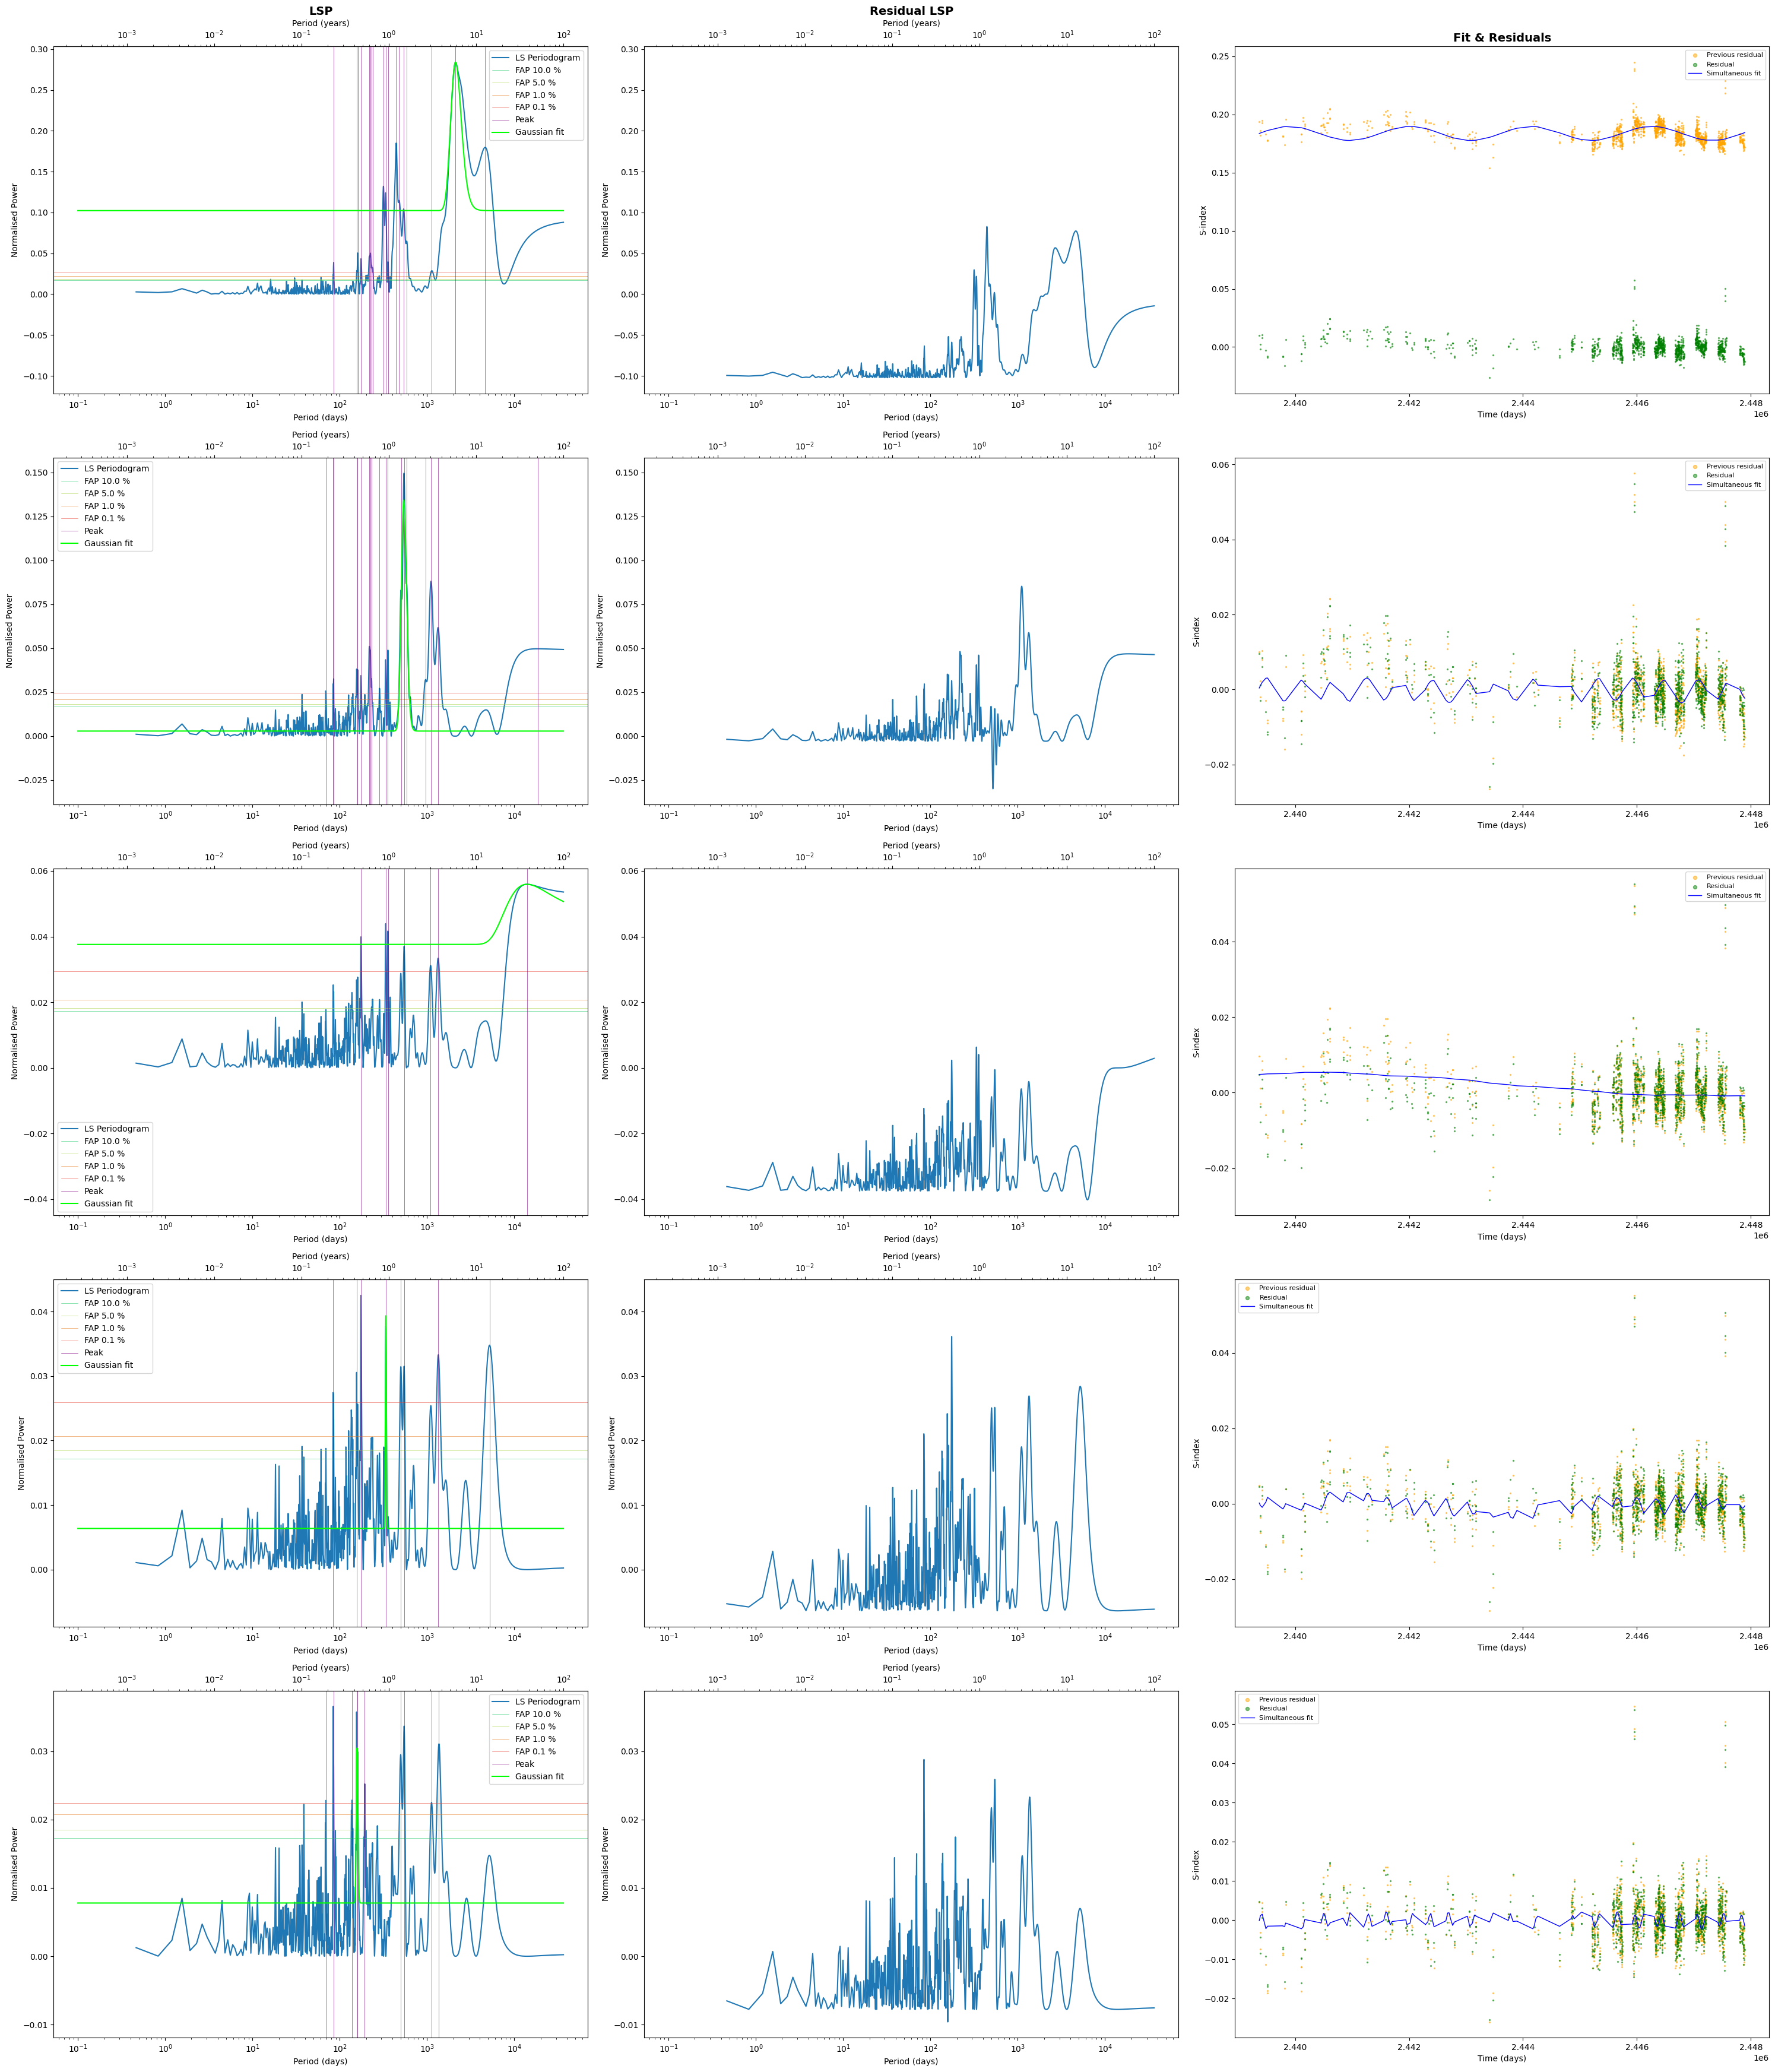

Accepted periods and their heights
+----------+-------+--------+------------+
|   Days   | Years | Height |    SNR     |
+----------+-------+--------+------------+
| 2120.40  |  5.81 | 0.2840 |  5648.09   |
|  581.91  |  1.59 | 0.0869 |    9.27    |
| 13977.15 | 38.29 | 0.0559 | 2096857.84 |
|  337.00  |  0.92 | 0.0378 |    8.13    |
|  155.96  |  0.43 | 0.0357 |    5.60    |
+----------+-------+--------+------------+


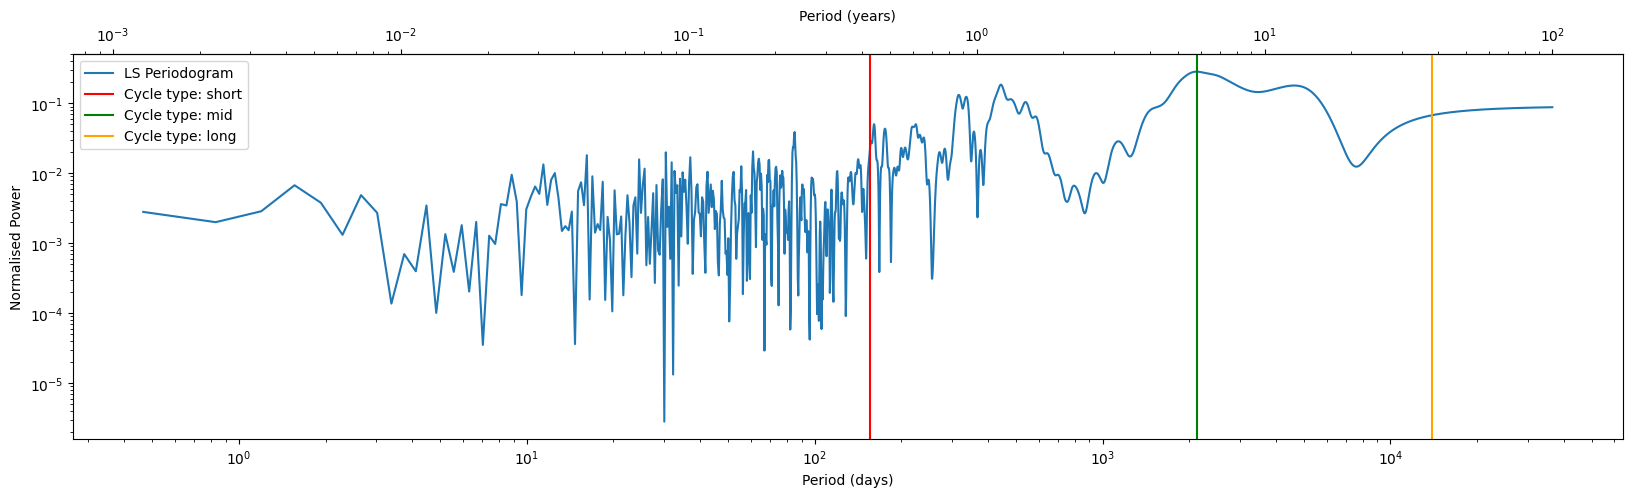

Classified Signals
+------------+------------+-------------+
| Cycle Type | Prior Days | Prior Years |
+------------+------------+-------------+
|   Short    |   155.96   |     0.43    |
|    Mid     |  2120.40   |     5.81    |
|    Long    |  13977.15  |    38.29    |
+------------+------------+-------------+


In [18]:
from helpers.priors import find_classify_signals

#--- set params

datapath = r"../../Data/hd18256_caii.txt"
add_prefix = True
relative = True
train_split = 0.8
valid_split = 0.19
verbose = True
plot = True

#---

raw_df = pd.read_csv(datapath, sep=r'\s+', skip_blank_lines=True)

# Prep the df adds the column names etc
data_df = prepare_df(raw_df, add_prefix=add_prefix, relative=relative)

# Split the data
dirty_train_df, valid_df, test_df = split_df(data_df,
                                                train_split=train_split, valid_split=valid_split)

# Clean the dataset for outliers
train_df = clean_df(dirty_train_df, tol=4,
                        verbose=verbose, plot=plot)

# Classify signal data and get priors
classified_signal_data = find_classify_signals(dirty_train_df,
                                        plot_fitpeaks=plot, verbose_fitpeaks=verbose,
                                        plot_genpriors=plot, verbose_genpriors=verbose)

## 2sm: HD10072


Removed 0 datapoints which had NaN.
Removed 24 datapoints that were deemed ourliers by tolerance in sind of 4 times MAD.


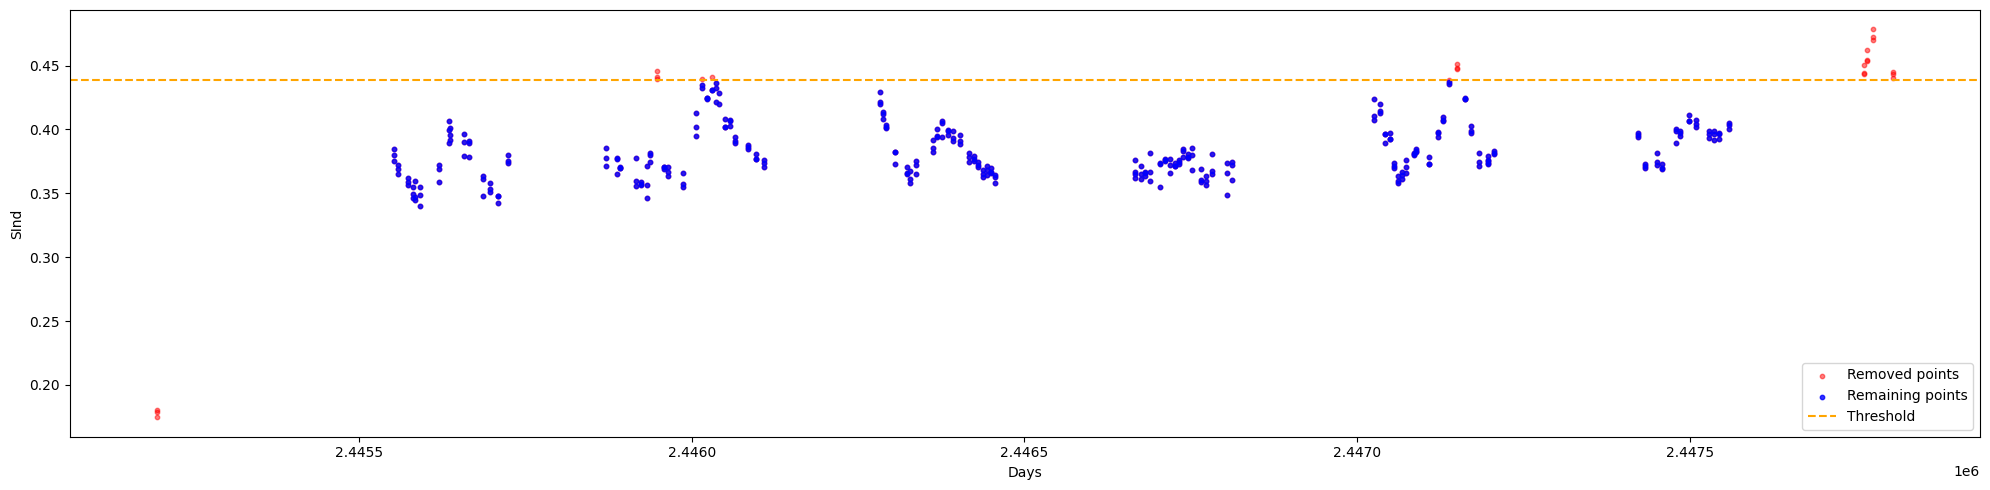

C:\Users\Joey\Desktop\Cambridge\Work\Thesis\helpers\LSP_peaks.py:173: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data_timeframe = t[-1] - t[0]


Peak at period 125.30 days was identified to be a window of 121.75 days by tolerance 0.03.
In iteration 0, period at 1516.69 days was accepted.
Peak at period 125.30 days was identified to be a window of 121.75 days by tolerance 0.03.
Peak at period 767.70 days was identified to be an alias of 1516.69 days at mult 0.50 by tolerance 0.01.
Peak at period 350.14 days was identified to be a window of 365.25 days by tolerance 0.04.
Peak at period 190.63 days was identified to be a window of 182.62 days by tolerance 0.04.
In iteration 1, period at 561.47 days was accepted.
Peak at period 125.66 days was identified to be a window of 121.75 days by tolerance 0.03.
Peak at period 726.09 days was identified to be an alias of 1516.69 days at mult 0.50 by tolerance 0.04.
Peak at period 351.96 days was identified to be a window of 365.25 days by tolerance 0.04.
Peak at period 189.17 days was identified to be an alias of 561.47 days at mult 0.33 by tolerance 0.01.
In iteration 2, period at 56.68 day

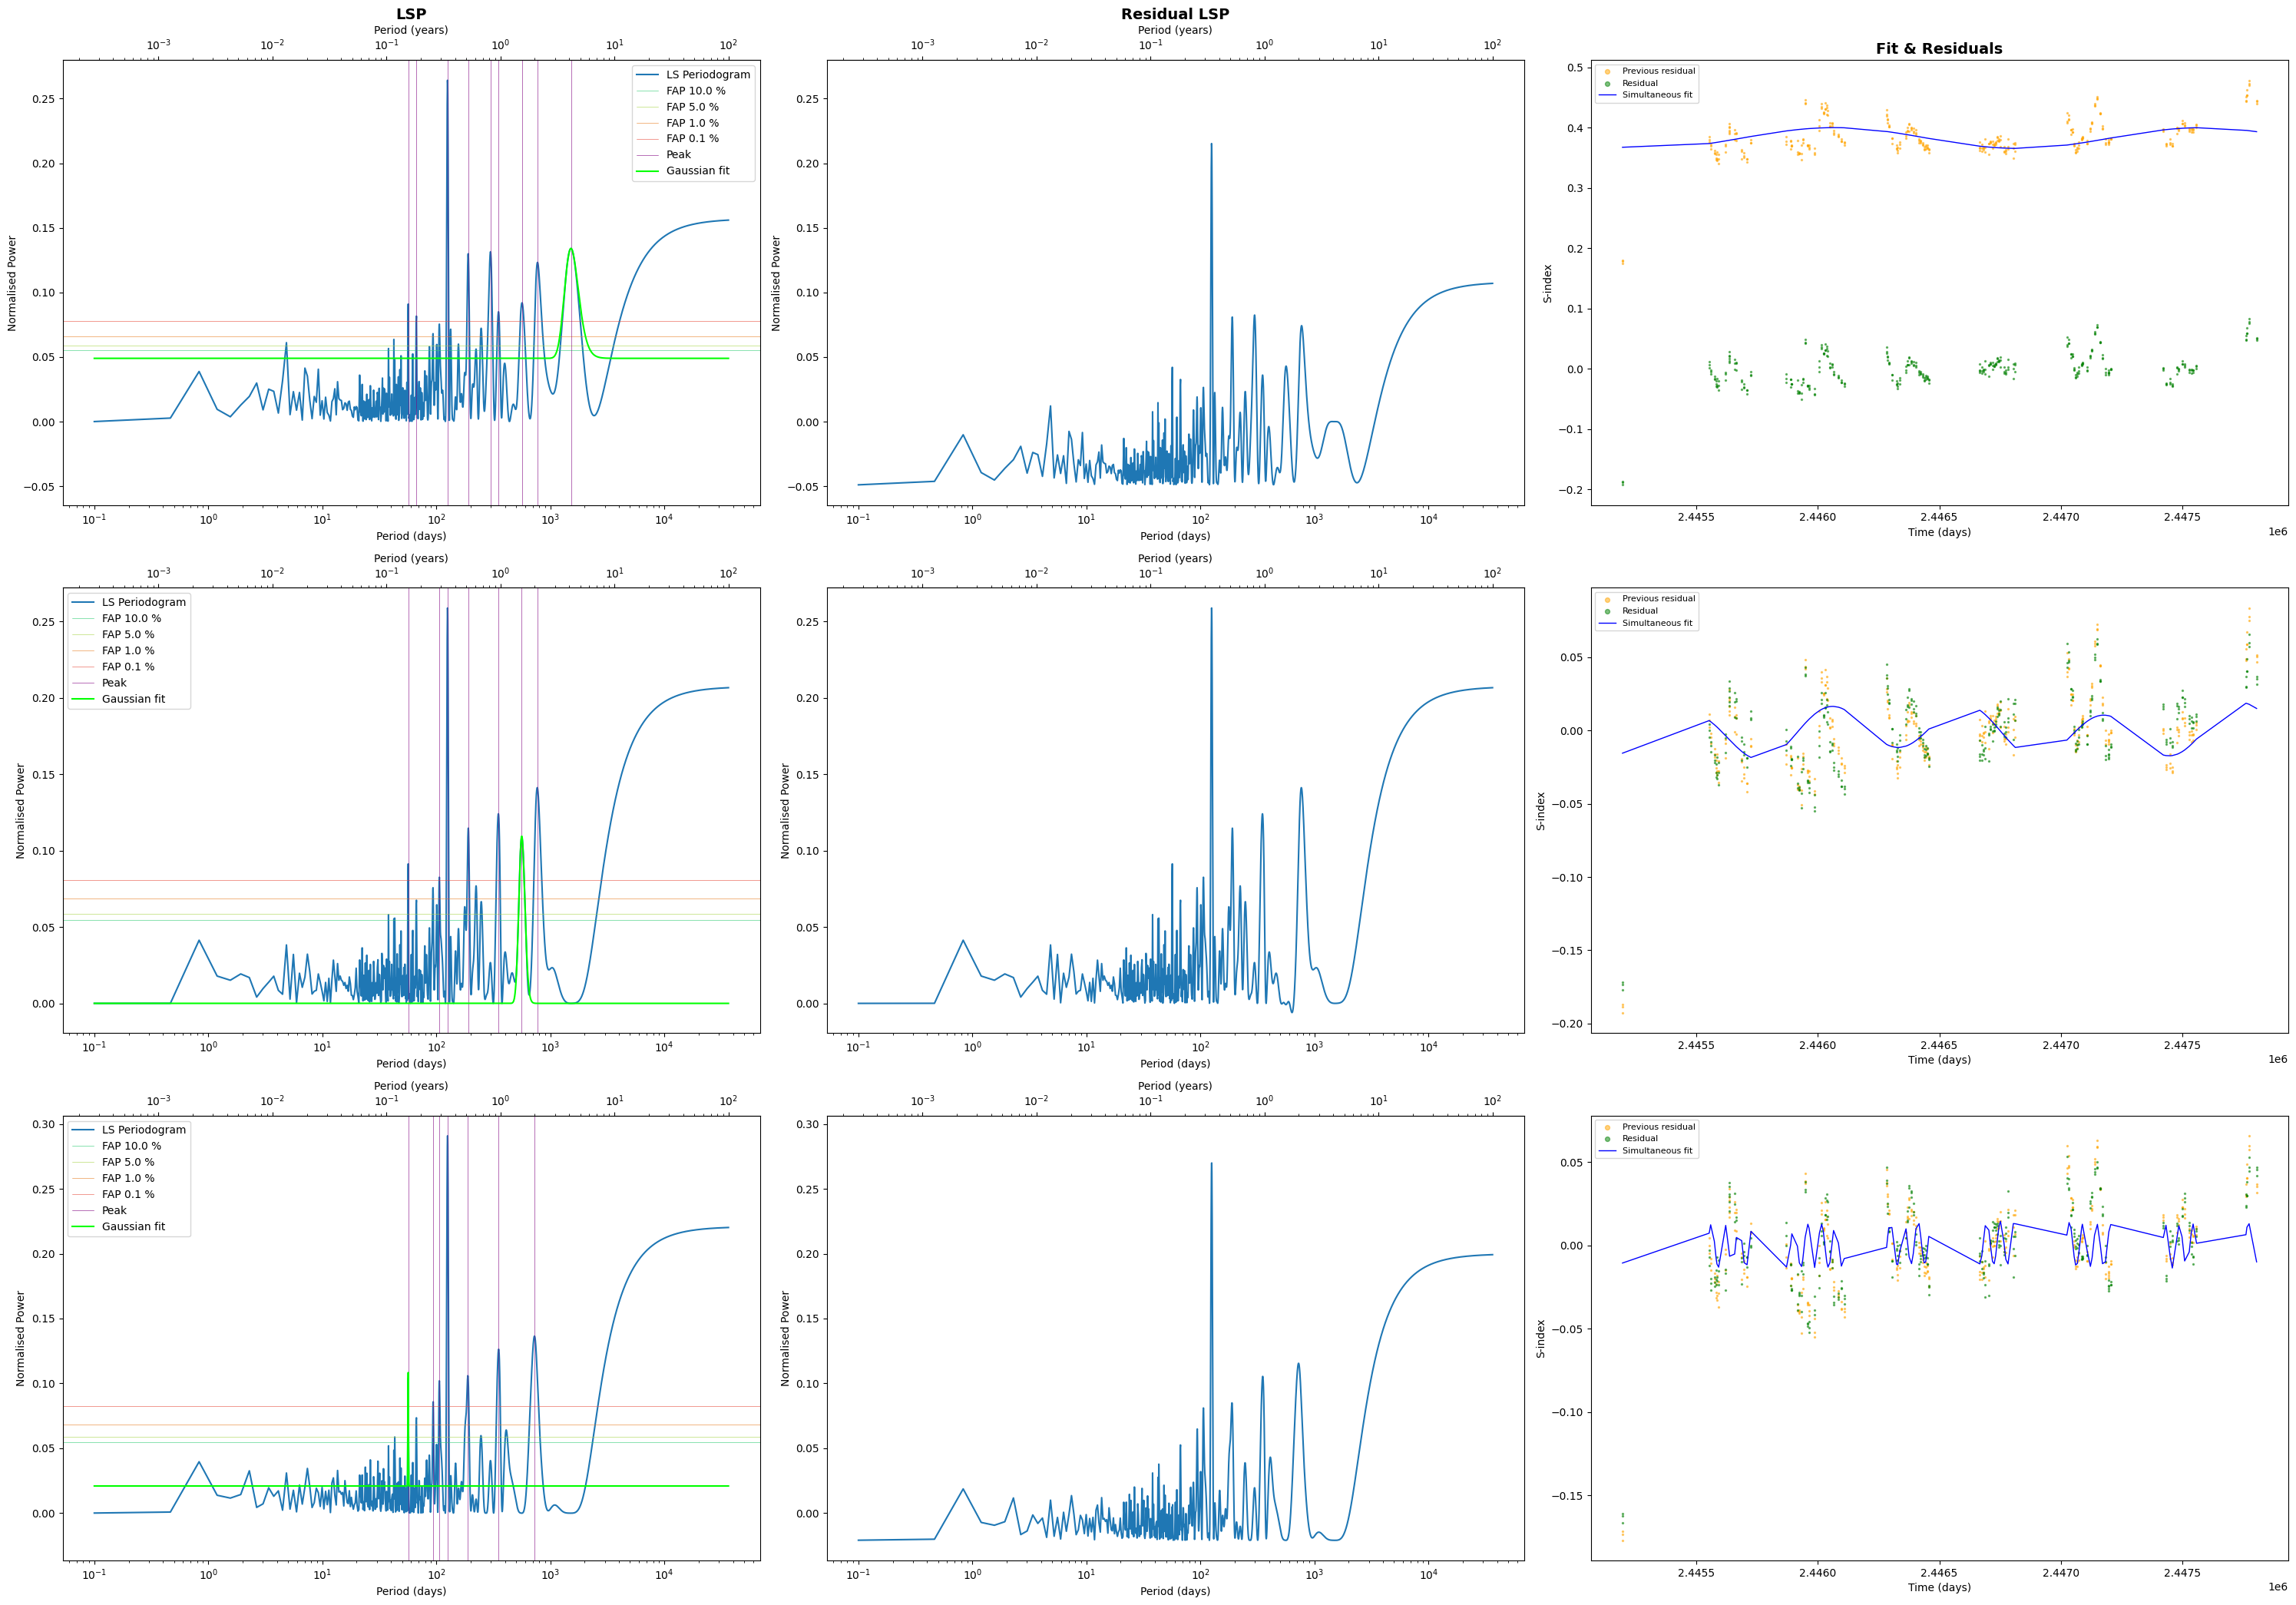

Accepted periods and their heights
+---------+-------+--------+----------+
|   Days  | Years | Height |   SNR    |
+---------+-------+--------+----------+
| 1516.69 |  4.16 | 0.1340 | 17986.31 |
|  561.47 |  1.54 | 0.1086 |  141.25  |
|  56.68  |  0.16 | 0.1041 |   5.07   |
+---------+-------+--------+----------+


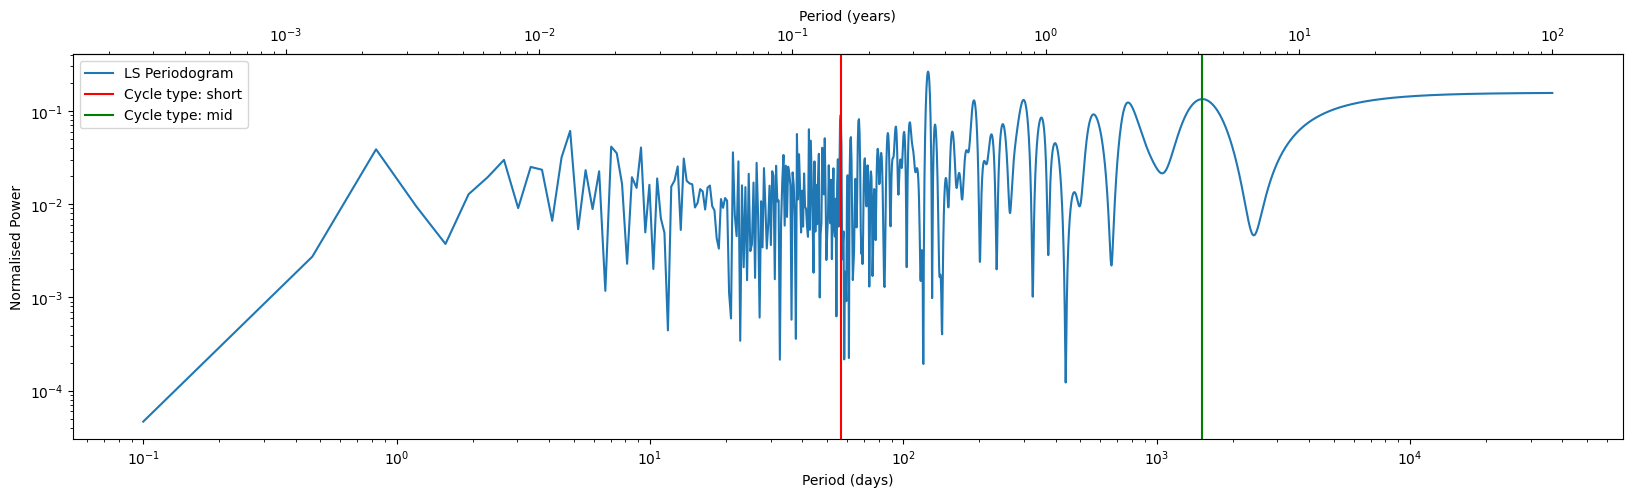

Classified Signals
+------------+------------+-------------+
| Cycle Type | Prior Days | Prior Years |
+------------+------------+-------------+
|   Short    |   56.68    |     0.16    |
|    Mid     |  1516.69   |     4.16    |
+------------+------------+-------------+


In [19]:
from helpers.priors import find_classify_signals

#--- set params

datapath = r"../../Data/hd10072_caii.txt"
add_prefix = True
relative = True
train_split = 0.8
valid_split = 0.19
verbose = True
plot = True

#---

raw_df = pd.read_csv(datapath, sep=r'\s+', skip_blank_lines=True)

# Prep the df adds the column names etc
data_df = prepare_df(raw_df, add_prefix=add_prefix, relative=relative)

# Split the data
dirty_train_df, valid_df, test_df = split_df(data_df,
                                                train_split=train_split, valid_split=valid_split)

# Clean the dataset for outliers
train_df = clean_df(dirty_train_df, tol=4,
                        verbose=verbose, plot=plot)

# Classify signal data and get priors
classified_signal_data = find_classify_signals(dirty_train_df,
                                        plot_fitpeaks=plot, verbose_fitpeaks=verbose,
                                        plot_genpriors=plot, verbose_genpriors=verbose)

## 2ml: HD16673


Removed 0 datapoints which had NaN.
Removed 19 datapoints that were deemed ourliers by tolerance in sind of 4 times MAD.


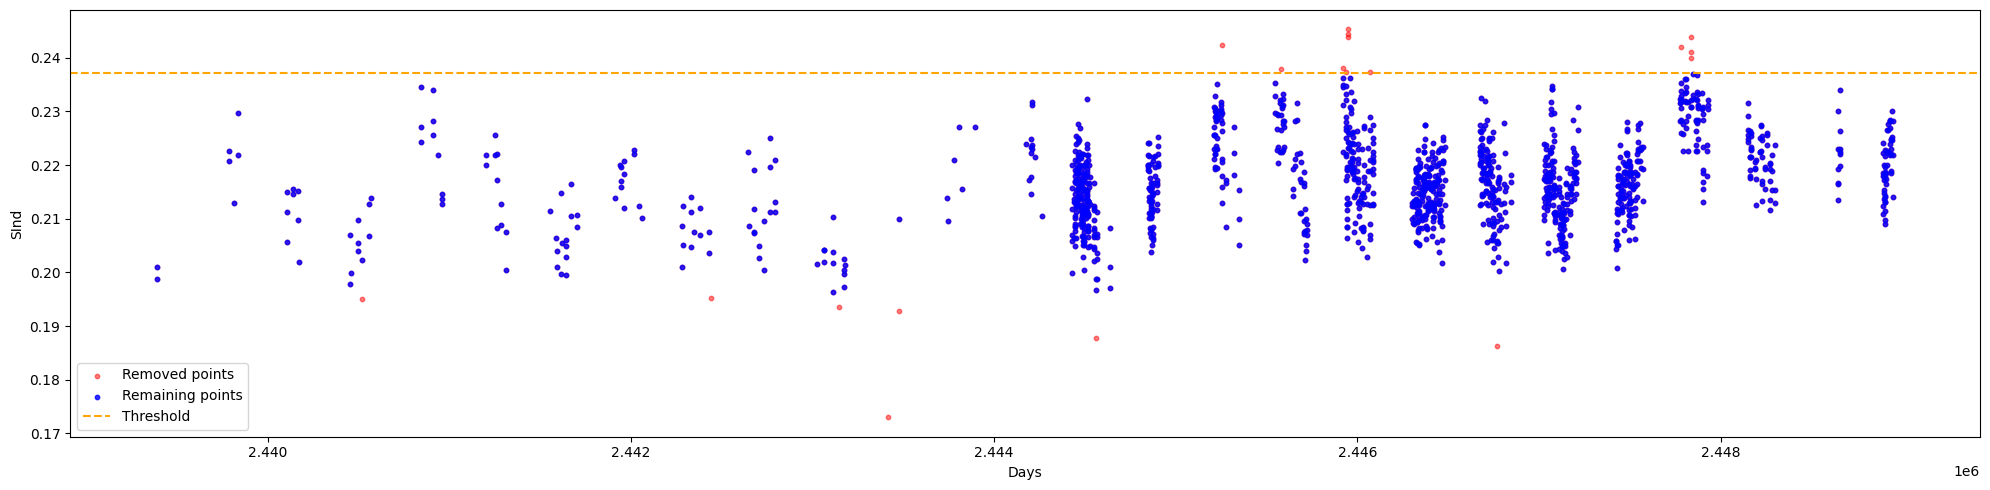

C:\Users\Joey\Desktop\Cambridge\Work\Thesis\helpers\LSP_peaks.py:173: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data_timeframe = t[-1] - t[0]


In iteration 0, period at 2292.68 days was accepted.
Peak at period 375.32 days was identified to be a window of 365.25 days by tolerance 0.03.
In iteration 1, period at 278.23 days was accepted.
Peak at period 376.42 days was identified to be a window of 365.25 days by tolerance 0.03.
In iteration 2, period at 995.83 days was accepted.
Peak at period 377.51 days was identified to be a window of 365.25 days by tolerance 0.03.
In iteration 3, period at 11631.27 days was accepted.
Peak at period 181.14 days was identified to be a window of 182.62 days by tolerance 0.01.
Peak at period 337.36 days was identified to be an alias of 995.83 days at mult 0.33 by tolerance 0.02.
Peak at period 363.28 days was identified to be a window of 365.25 days by tolerance 0.01.
Peak at period 185.52 days was identified to be a window of 182.62 days by tolerance 0.02.
In iteration 4, period at 3516.17 days was accepted.
In iteration 5, period at 1378.35 days was accepted.
Peak at period 124.93 days was id

c:\Users\Joey\Desktop\Cambridge\Work\Thesis\VenvThesis\lib\site-packages\numpy\_core\_methods.py:191: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


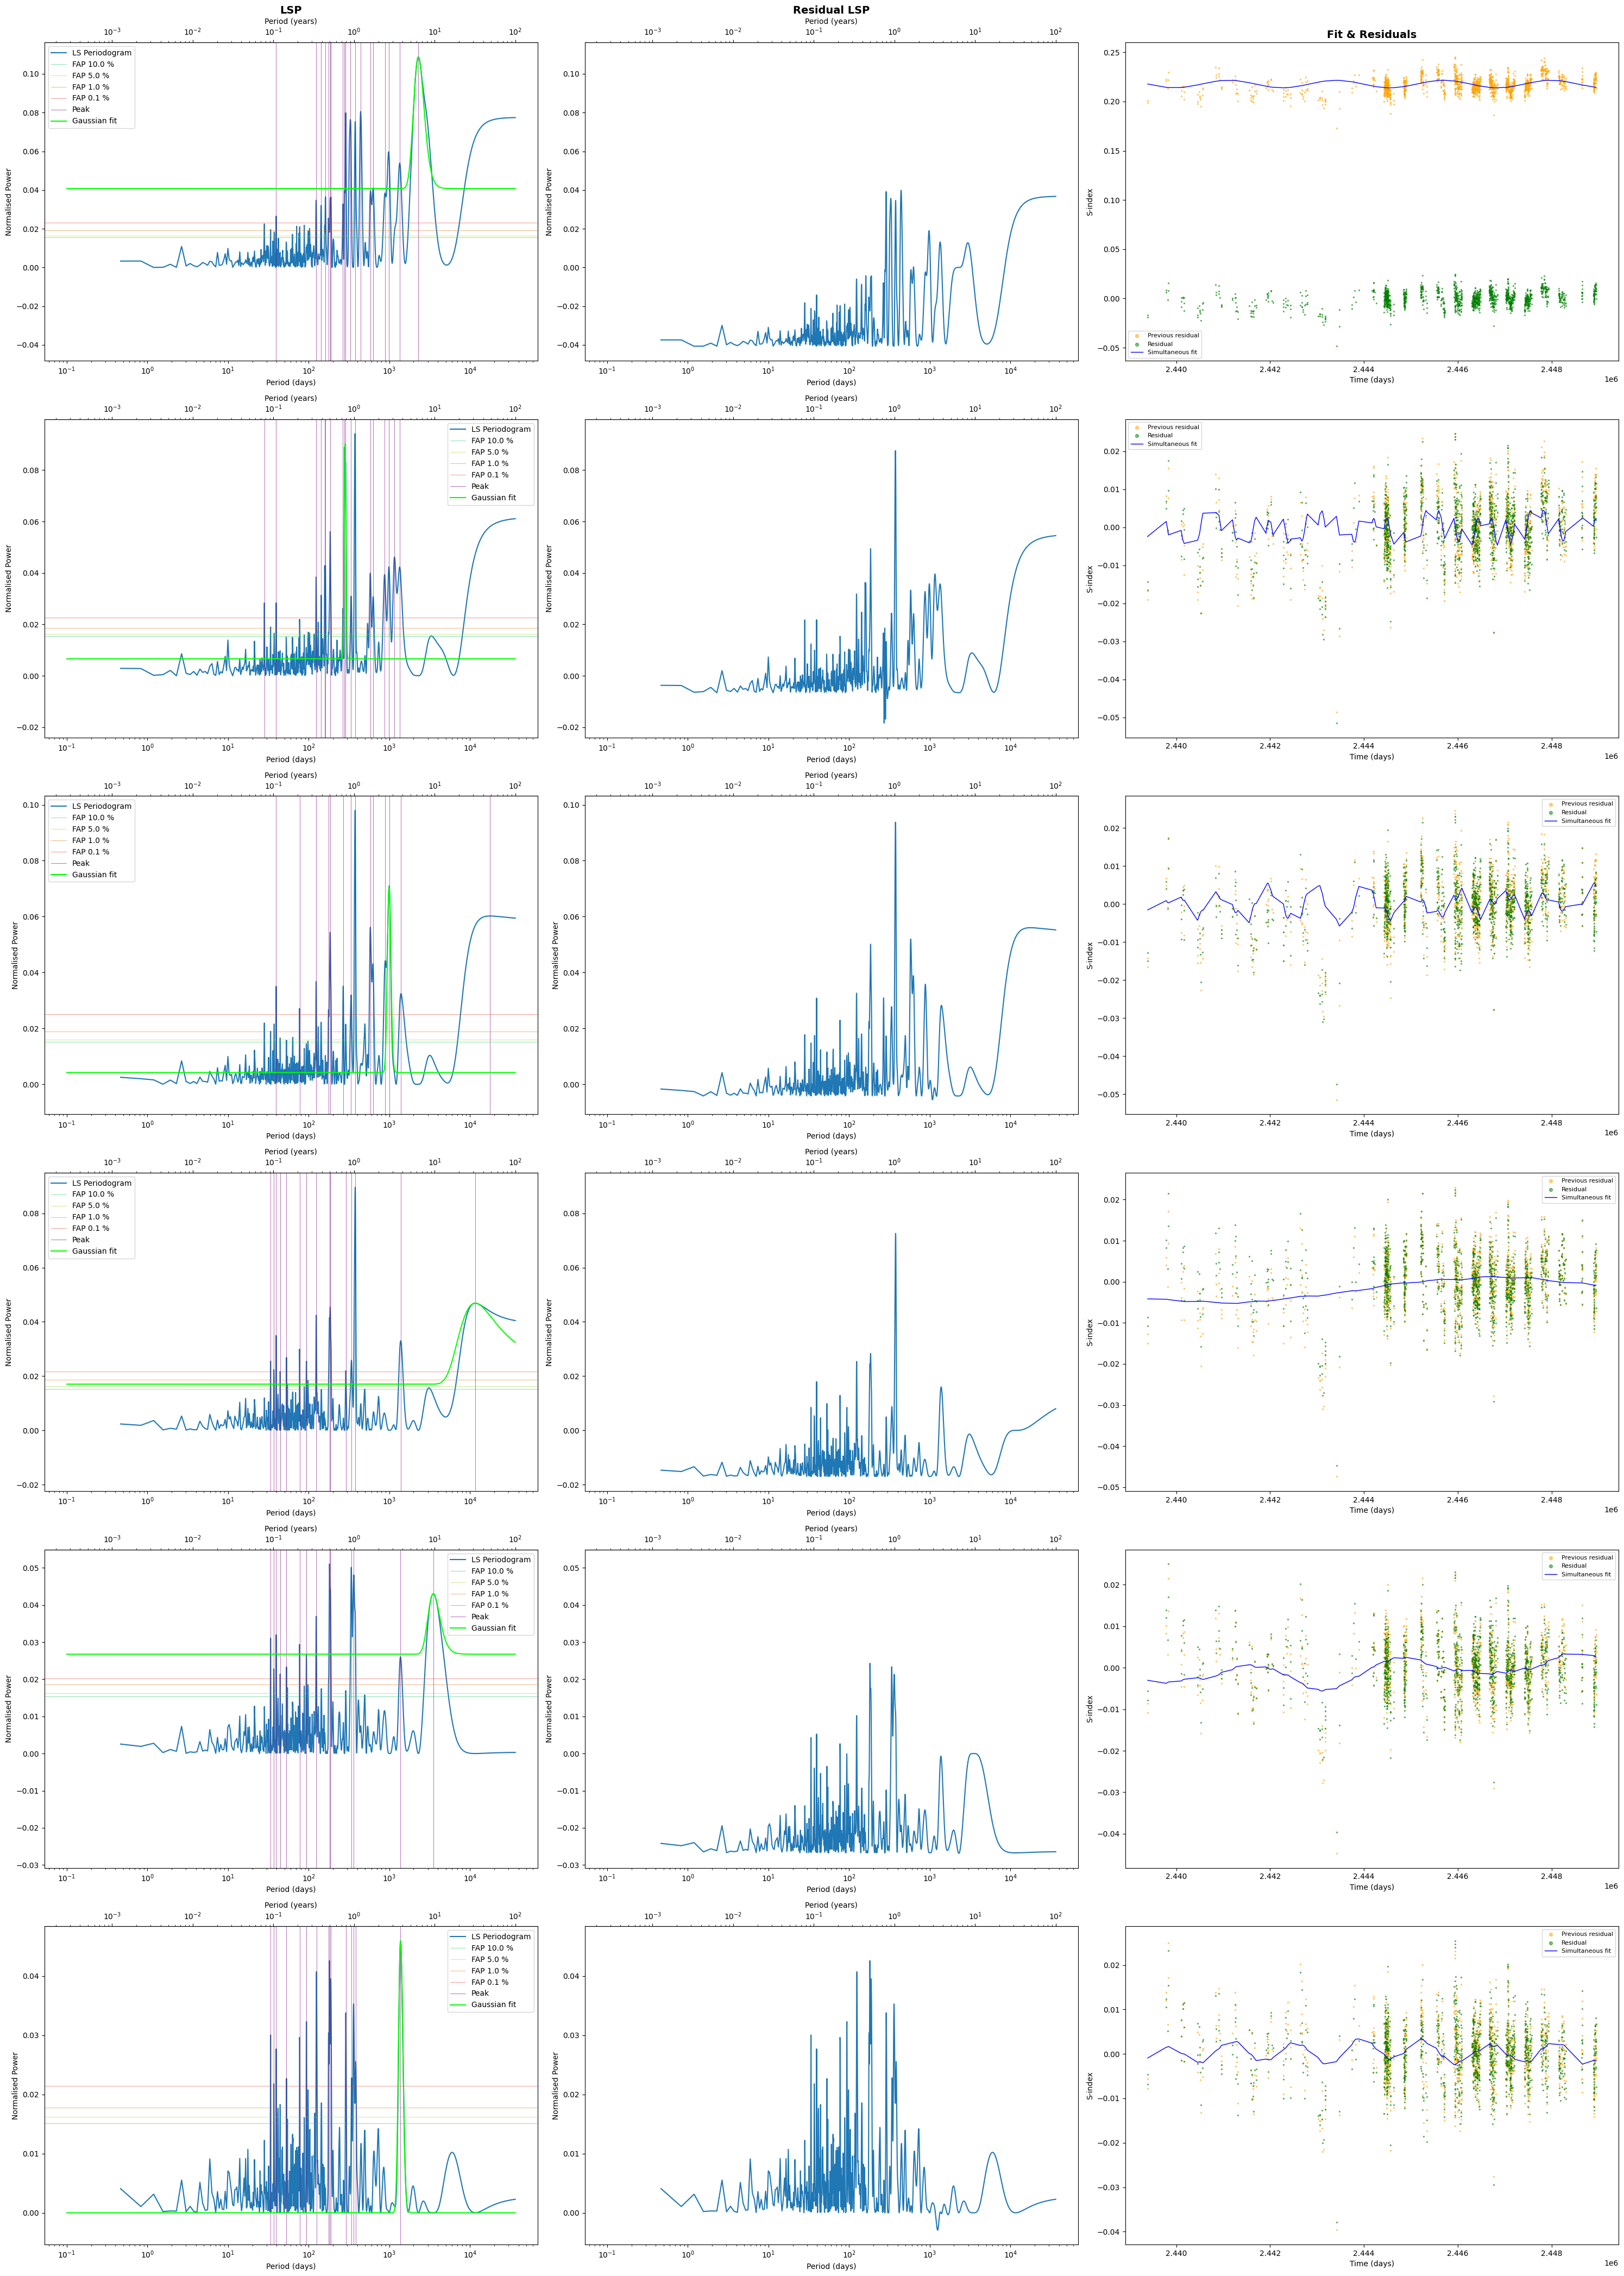

Accepted periods and their heights
+----------+-------+--------+-----------+
|   Days   | Years | Height |    SNR    |
+----------+-------+--------+-----------+
| 2292.68  |  6.28 | 0.1087 |  75659.11 |
|  278.23  |  0.76 | 0.0889 |   10.94   |
|  995.83  |  2.73 | 0.0709 |   51.85   |
| 11631.27 | 31.87 | 0.0469 | 646408.26 |
| 3516.17  |  9.63 | 0.0430 | 643714.72 |
| 1378.35  |  3.78 | 0.0459 |   407.97  |
+----------+-------+--------+-----------+


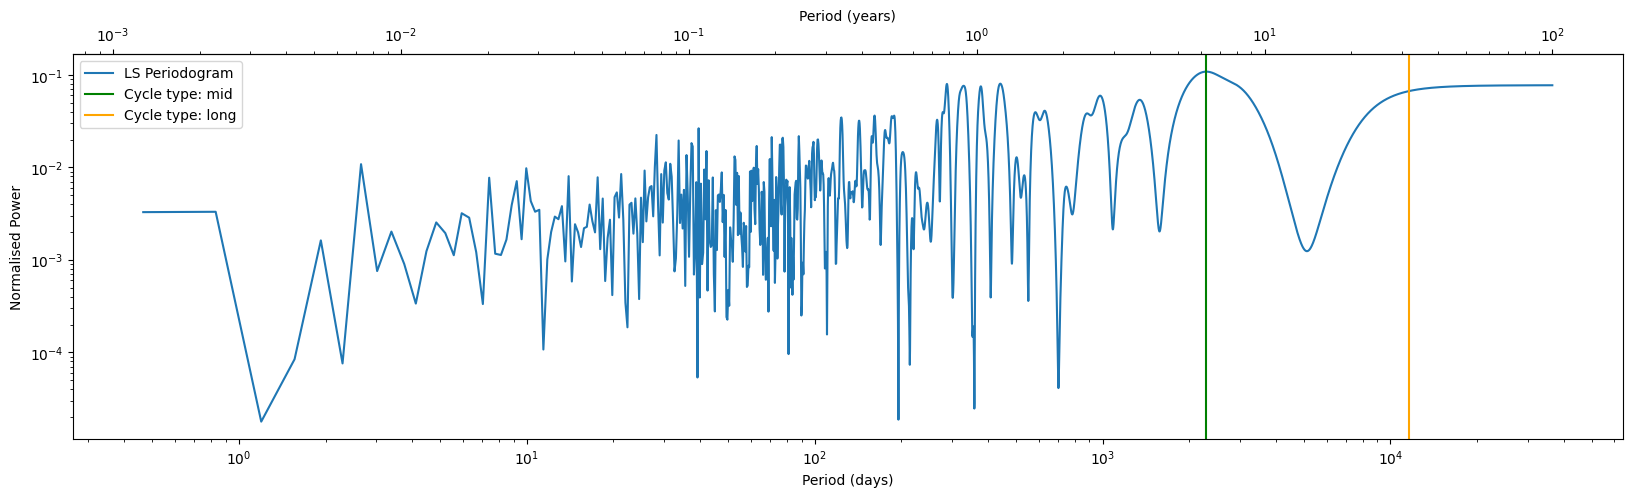

Classified Signals
+------------+------------+-------------+
| Cycle Type | Prior Days | Prior Years |
+------------+------------+-------------+
|    Mid     |  2292.68   |     6.28    |
|    Long    |  11631.27  |    31.87    |
+------------+------------+-------------+


In [21]:
from helpers.priors import find_classify_signals

#--- set params

datapath = r"../../Data/hd16673_caii.txt"
add_prefix = True
relative = True
train_split = 0.8
valid_split = 0.19
verbose = True
plot = True

#---

raw_df = pd.read_csv(datapath, sep=r'\s+', skip_blank_lines=True)

# Prep the df adds the column names etc
data_df = prepare_df(raw_df, add_prefix=add_prefix, relative=relative)

# Split the data
dirty_train_df, valid_df, test_df = split_df(data_df,
                                                train_split=train_split, valid_split=valid_split)

# Clean the dataset for outliers
train_df = clean_df(dirty_train_df, tol=4,
                        verbose=verbose, plot=plot)

# Classify signal data and get priors
classified_signal_data = find_classify_signals(dirty_train_df,
                                        plot_fitpeaks=plot, verbose_fitpeaks=verbose,
                                        plot_genpriors=plot, verbose_genpriors=verbose)

## 1m: HD11131


Removed 0 datapoints which had NaN.
Removed 0 datapoints that were deemed ourliers by tolerance in sind of 4 times MAD.


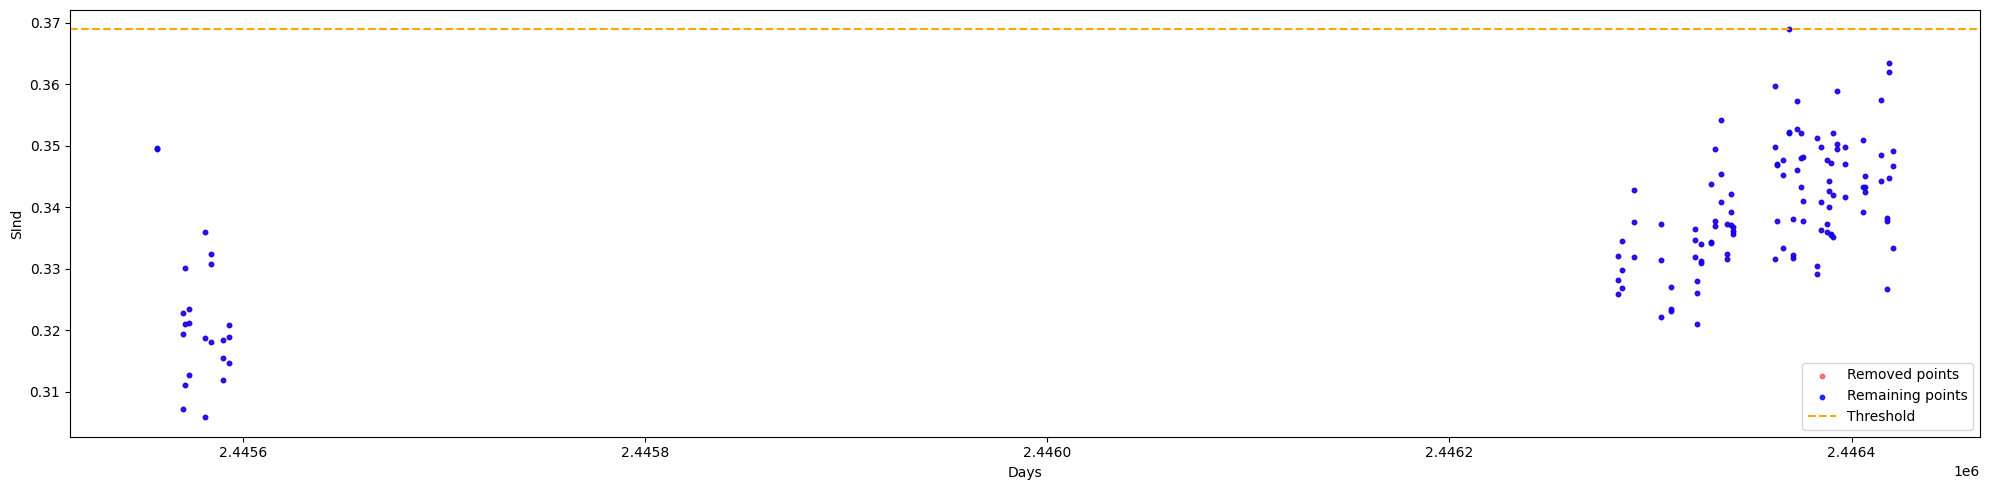

C:\Users\Joey\Desktop\Cambridge\Work\Thesis\helpers\LSP_peaks.py:173: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data_timeframe = t[-1] - t[0]


In iteration 0, period at 981.96 days was accepted.


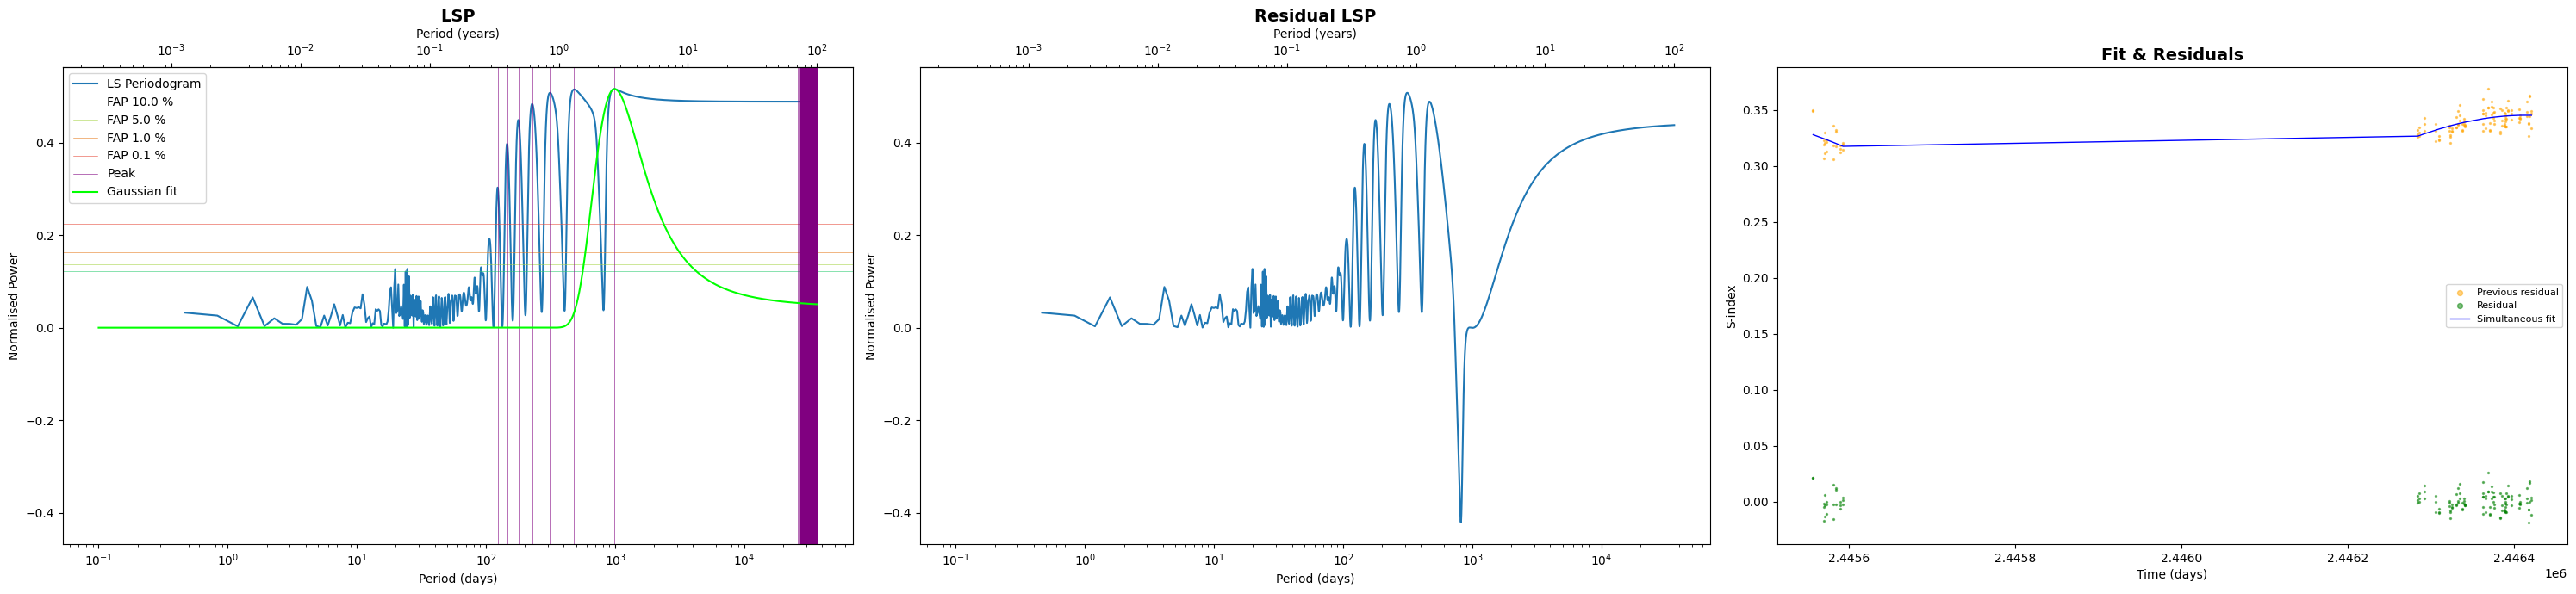

Accepted periods and their heights
+--------+-------+--------+---------+
|  Days  | Years | Height |   SNR   |
+--------+-------+--------+---------+
| 981.96 |  2.69 | 0.5160 | 1591.51 |
+--------+-------+--------+---------+


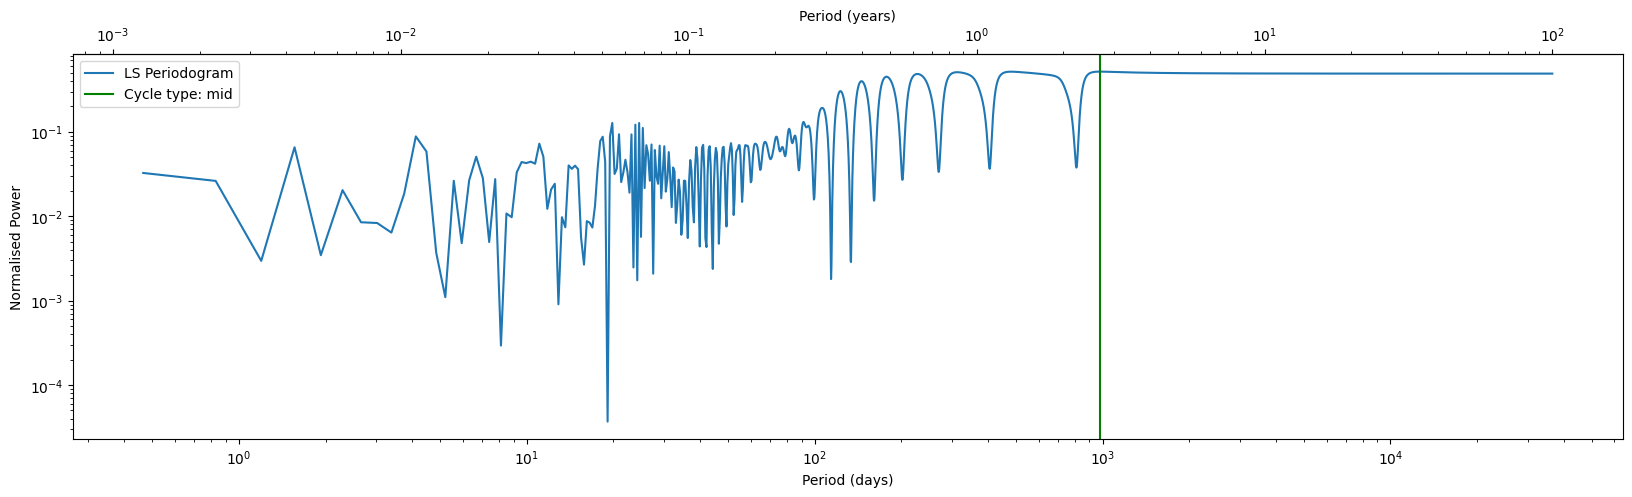

Classified Signals
+------------+------------+-------------+
| Cycle Type | Prior Days | Prior Years |
+------------+------------+-------------+
|    Mid     |   981.96   |     2.69    |
+------------+------------+-------------+


In [20]:
from helpers.priors import find_classify_signals

#--- set params

datapath = r"../../Data/hd11131_caii.txt"
add_prefix = True
relative = True
train_split = 0.8
valid_split = 0.19
verbose = True
plot = True

#---

raw_df = pd.read_csv(datapath, sep=r'\s+', skip_blank_lines=True)

# Prep the df adds the column names etc
data_df = prepare_df(raw_df, add_prefix=add_prefix, relative=relative)

# Split the data
dirty_train_df, valid_df, test_df = split_df(data_df,
                                                train_split=train_split, valid_split=valid_split)

# Clean the dataset for outliers
train_df = clean_df(dirty_train_df, tol=4,
                        verbose=verbose, plot=plot)

# Classify signal data and get priors
classified_signal_data = find_classify_signals(dirty_train_df,
                                        plot_fitpeaks=plot, verbose_fitpeaks=verbose,
                                        plot_genpriors=plot, verbose_genpriors=verbose)

## 0: HD10700


Removed 0 datapoints which had NaN.
Removed 34 datapoints that were deemed ourliers by tolerance in sind of 4 times MAD.


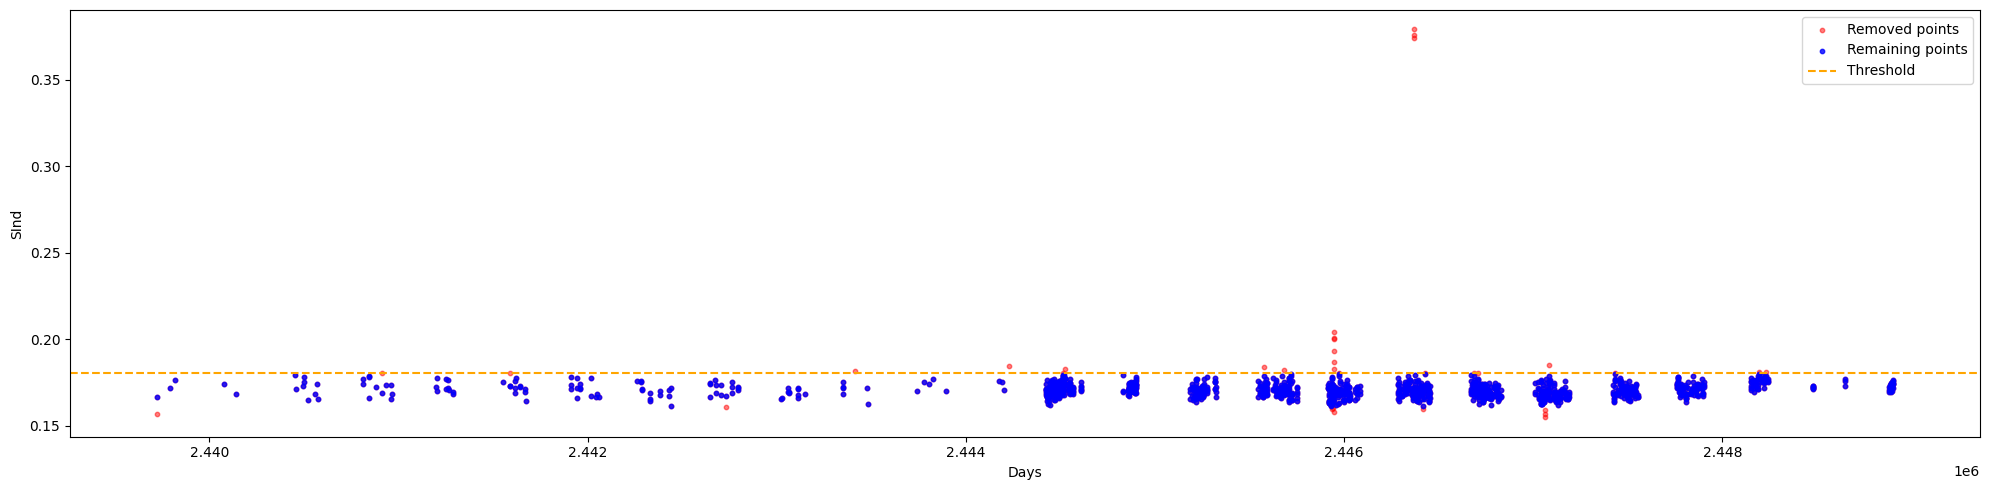

C:\Users\Joey\Desktop\Cambridge\Work\Thesis\helpers\LSP_peaks.py:173: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data_timeframe = t[-1] - t[0]


ValueError: Number of rows must be a positive integer, not 0

<Figure size 3000x0 with 0 Axes>

In [23]:
from helpers.priors import find_classify_signals

#--- set params

datapath = r"../../Data/hd10700_caii.txt"
add_prefix = True
relative = True
train_split = 0.8
valid_split = 0.19
verbose = True
plot = True

#---

raw_df = pd.read_csv(datapath, sep=r'\s+', skip_blank_lines=True)

# Prep the df adds the column names etc
data_df = prepare_df(raw_df, add_prefix=add_prefix, relative=relative)

# Split the data
dirty_train_df, valid_df, test_df = split_df(data_df,
                                                train_split=train_split, valid_split=valid_split)

# Clean the dataset for outliers
train_df = clean_df(dirty_train_df, tol=4,
                        verbose=verbose, plot=plot)

# Classify signal data and get priors
classified_signal_data = find_classify_signals(dirty_train_df,
                                        plot_fitpeaks=plot, verbose_fitpeaks=verbose,
                                        plot_genpriors=plot, verbose_genpriors=verbose)